In [2]:
import numpy as np
from pylab import gca
import numpy as np
import math
from tqdm import tqdm
import torch
import torchvision
from datasets.dataset import SimulationXZDataset
import time 
import time 
import torch.nn as nn
from torch.utils import data
import torch.nn.functional as F
from torchvision import transforms
from torchvision.utils import save_image
from torchvision.datasets import MNIST
import torchvision.transforms.functional as TF
from torch.optim import lr_scheduler
import time
import os

from skimage.metrics import structural_similarity as ssim_id
import numpy as np
import cv2
import os
from torchvision import transforms
from torch.utils.data import DataLoader
from pathlib import Path
from torch.utils.data import Dataset
import pdb
from PIL import Image
import matplotlib.pyplot as plt 
# from datasets.dataset import TemperatureXZDataset
from runners.train_diffusion import forwardpass
from analysis_functions import predict_lrenc, predict_mobilenet, plot_images, get_profile, load_mobilenet, load_encoder, load_diffusion, PSNR, SSIM, predict_modified_diffusion

In [2]:
def frame_tick(frame_width = 2, tick_width = 1.5):
    ax = gca()
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(frame_width)
    plt.tick_params(direction = 'in', 
                    width = tick_width)
def legend(location = 'best', fontsize = 8):
        plt.legend(loc = location, fontsize = fontsize, frameon = False)

In [88]:
cross_5 = np.load('/home/oogoke/DiffusionSR/analysis/transfer_analysis/myoutput.melt_power_259_velocity_700_5micron/data50.npz', allow_pickle=True)['temperature'][1:].astype('float')[:,60,:]
cross_20 = np.load('/home/oogoke/DiffusionSR/analysis/transfer_analysis/myoutput.melt_power_259_velocity_700_20micron/data50.npz', allow_pickle=True)['temperature'][1:].astype('float')[:,15,:]

In [84]:
ss316l_lr.shape

(50, 20)

In [110]:
ss316l_lr = cross_20[:20, 0:20]


In [112]:
ss316l_lr = cross_20[:20 :20]
plt.imshow(ss316l_lr.T, origin = 'lower')
plt.show()
ss316l_hr = cross_20[:80, :80]


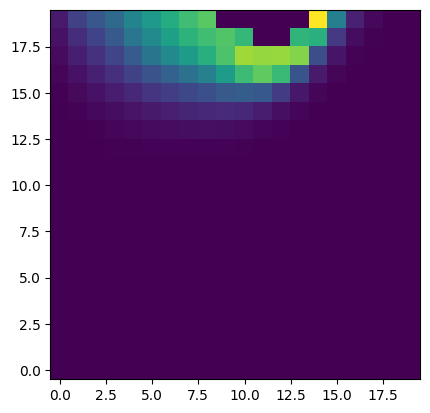

In [111]:
velocities = []


profiles_all =[]
i = 0

velocities_high = []
powers_high = []
profiles_all =[]
i = 0

from skimage import transform
# for idx in range(100):
hr_frame = np.load('/home/oogoke/DiffusionSR/analysis/transfer_analysis/myoutput.melt_power_259_velocity_700_5micron/data50.npz', allow_pickle=True)['temperature'][1:].astype('float')[:,60,:]
lr_frame = np.load('/home/oogoke/DiffusionSR/analysis/transfer_analysis/myoutput.melt_power_259_velocity_700_20micron/data50.npz', allow_pickle=True)['temperature'][1:].astype('float')[:,15,:]

vapor_dep_array = np.zeros((100, hr_frame.shape[0])) # num samples x liqlabelframe.shape[0]  = 100 X 200
max_depth = []


print("Now processing: " + str(i))

for i in range(0,100):
    profiles = []
    # directory = pdir + direct
    # if highres:
    #     low_res_dir = lowrespdir+lowresdirectories[verify_dirs.index(check_dirs[current_dirs.index(direct)])]
    # try:
    #     liqlabelframe = np.loadtxt(directory+'/currentliqlabel' + str(1000 + i) +  '.txt')
    # except:
    #     liqlabelframe = np.loadtxt(directory + '/depth_boolean' + str(1000 + i) +  '.txt')
    # depthbooleanframe = np.loadtxt(directory + '/depth_boolean' + str(1000 + i) +  '.txt')
    tempframe = np.load('/home/oogoke/DiffusionSR/analysis/transfer_analysis/myoutput.melt_power_259_velocity_700_5micron/data{:02d}.npz'.format(i), allow_pickle=True)['temperature'][1:].astype('float')[:,60,:]

    lowrestempframe = np.load('/home/oogoke/DiffusionSR/analysis/transfer_analysis/myoutput.melt_power_259_velocity_700_20micron/data{:02d}.npz'.format(i), allow_pickle=True)['temperature'][1:].astype('float')[:,15,:]


    # lowrestempframe = np.loadtxt(low_res_dir +  '/temperature' + str(1000 + i) + '.txt')
    lowrestempframe_resized = transform.resize(lowrestempframe, (tempframe.shape))
    ax = plt.gca()
    ax.set_facecolor('w')
    img_size = 80
    padsize = img_size//2
    power = direct.split('power_')[1].split('_velocity')[0]
    velocity = direct.split('velocity_')[1]
    theta_pad = np.copy(np.pad(tempframe, ((padsize, padsize), (0, 0)), mode = 'constant', constant_values = 293))
    low_res_tempframe =  np.copy(np.pad(lowrestempframe_resized, ((padsize, padsize), (0, 0)), mode = 'constant', constant_values = 293))
    
    
    if np.std(tempframe) == 0:
        squareim = np.ones((img_size,img_size))*293
        continue
    try:
        idx_max = np.argmax(np.sum(theta_pad, axis = 1)) 
        low_res_idx_max = np.argmax(np.sum(low_res_tempframe, axis = 1))
    except:
        idx_max = theta_pad.shape[0]//2
        low_res_idx_max  = low_res_tempframe.shape[0]//2
    
    squareim = theta_pad[idx_max-img_size//2:idx_max+img_size//2, :img_size]
    squareimlowres = low_res_tempframe[idx_max-img_size//2:idx_max+img_size//2, :img_size]

    lowresliqlabel = np.loadtxt(low_res_dir + '/currentliqlabel' + str(1000 + i) +  '.txt')

    # breakpoint()
    plt.imshow(squareim.T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
    plt.show()
    plt.imshow(squareimlowres.T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
    plt.show()
    # plt.imshow(squareimlowres.T, origin = 'lower', cmap = 'jet', vmin = 293)
    # plt.savefig('superres_data' + '/lowrestempsquare' + 'power'+ str(power)+'velocity'+str(velocity)+'_'+ str(i+1000) + '.png')
    # plt.imshow(squareim.T, origin = 'lower', cmap = 'jet', vmin = 293)
    # plt.savefig('superres_data' + '/highrestempsquare' + 'power'+ str(power)+'velocity'+str(velocity)+'_'+ str(i+1000) + '.png')

    oldtime = time.time()
    filtered_image = ndimage.uniform_filter(squareim, size = 10)
    print(time.time() - oldtime)

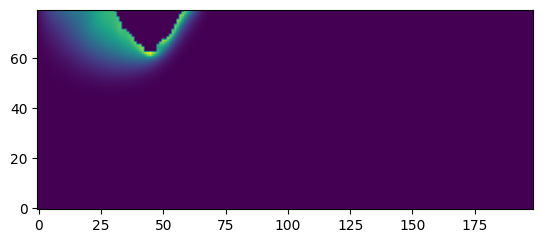

In [91]:
plt.imshow(cross_5[:,:80].T, origin = 'lower')

25 15 35
(20, 20)


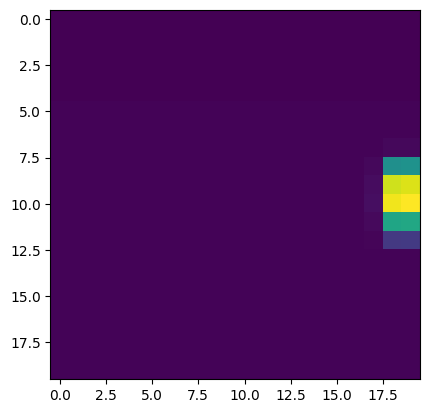

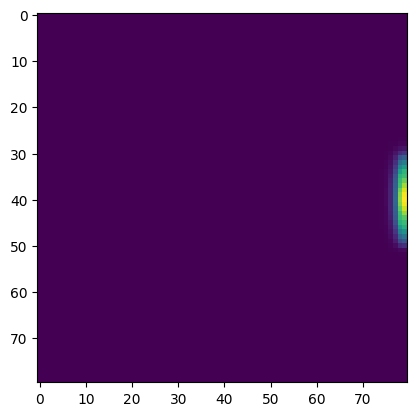

25 15 35
(20, 20)


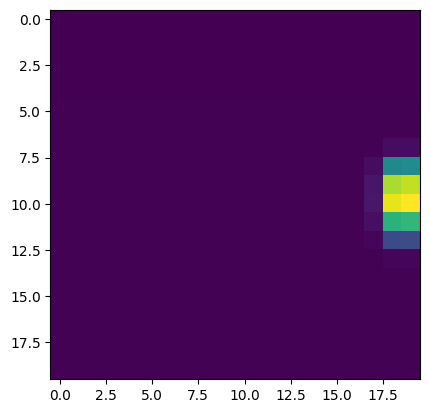

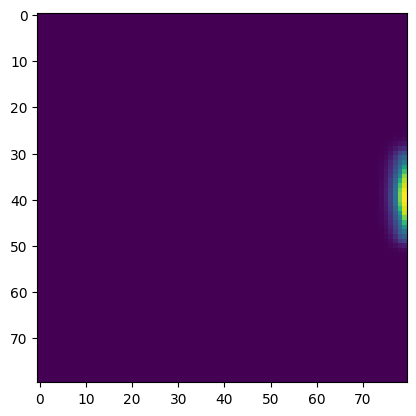

25 15 35
(20, 20)


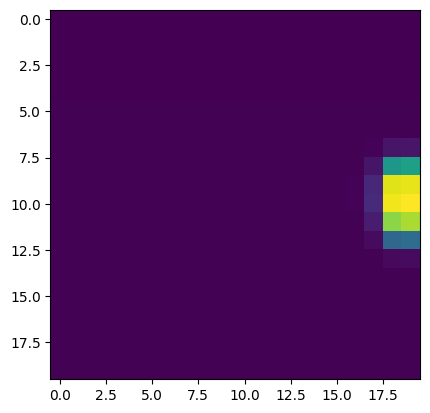

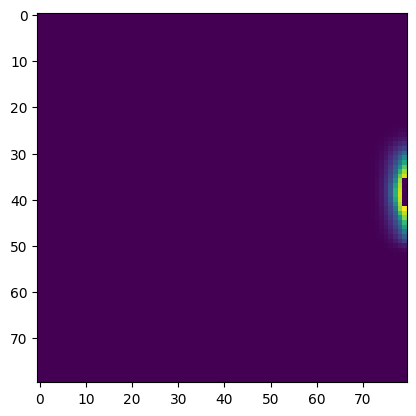

25 15 35
(20, 20)


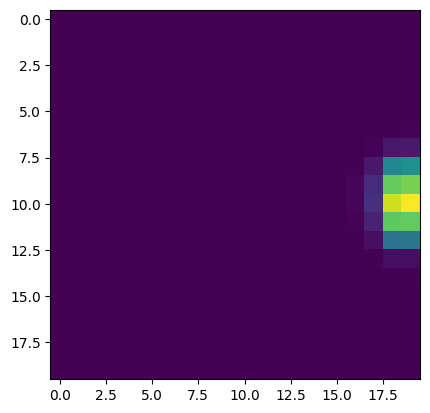

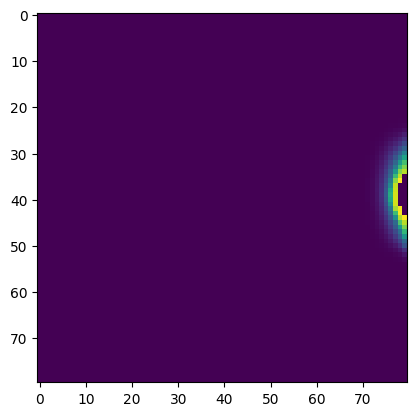

25 15 35
(20, 20)


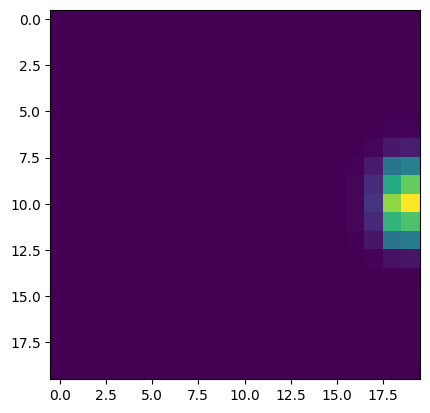

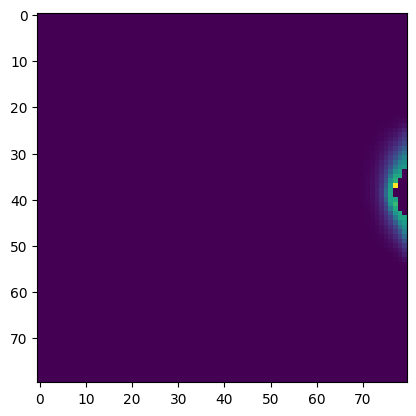

26 16 36
(20, 20)


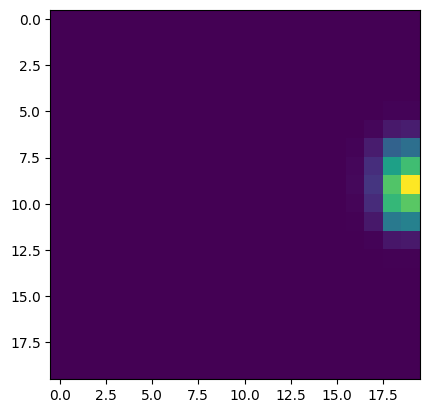

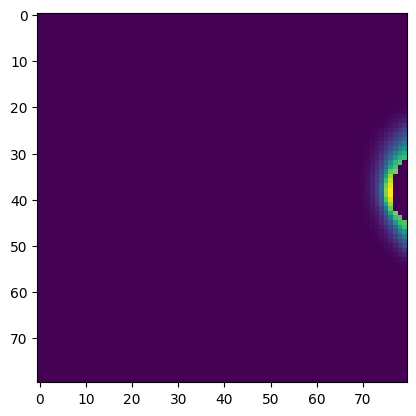

26 16 36
(20, 20)


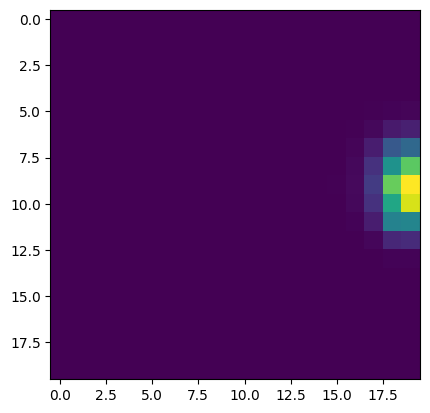

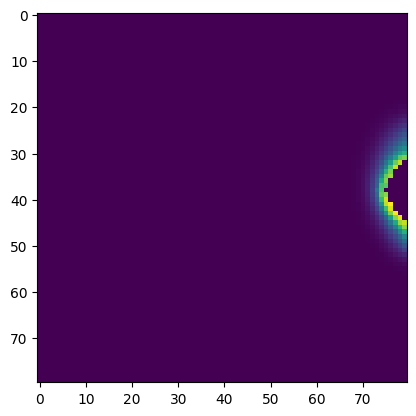

26 16 36
(20, 20)


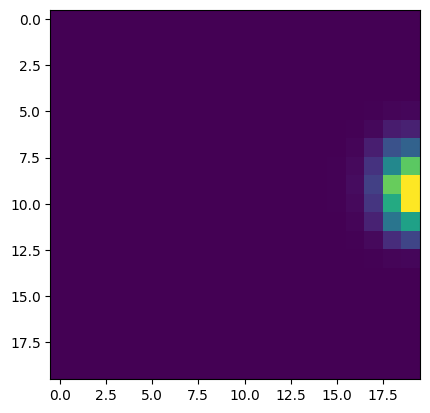

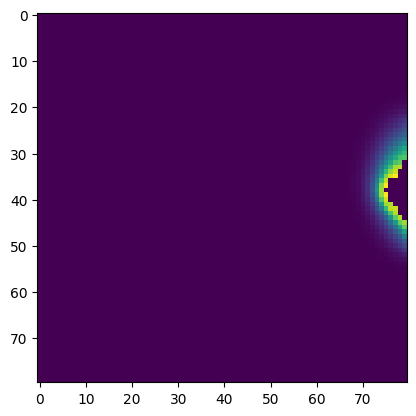

26 16 36
(20, 20)


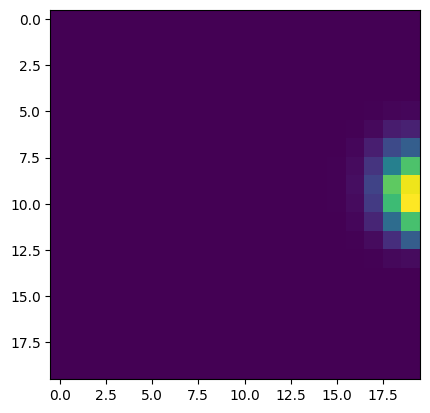

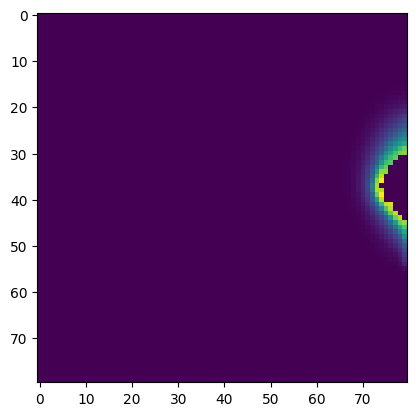

26 16 36
(20, 20)


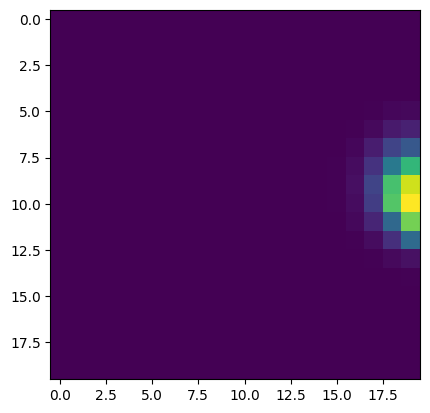

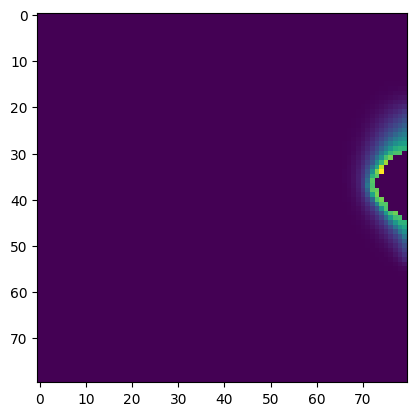

26 16 36
(20, 20)


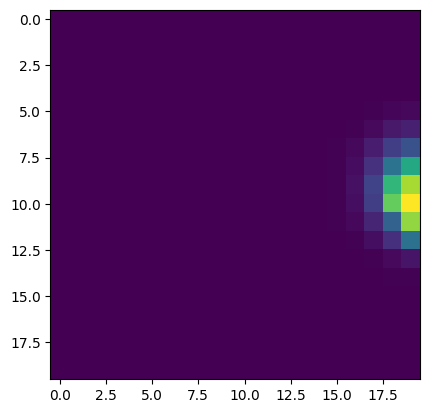

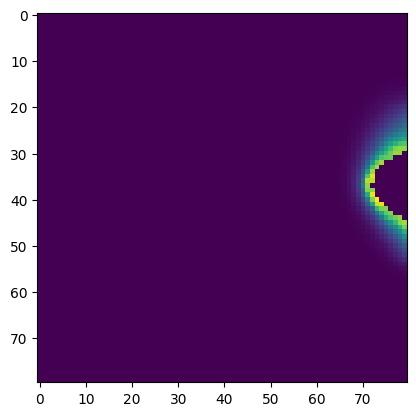

27 17 37
(20, 20)


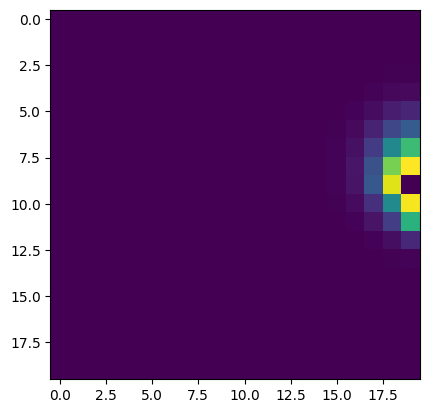

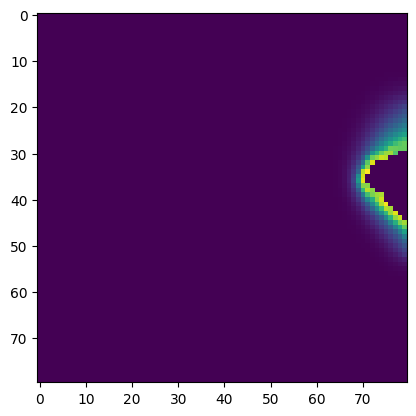

27 17 37
(20, 20)


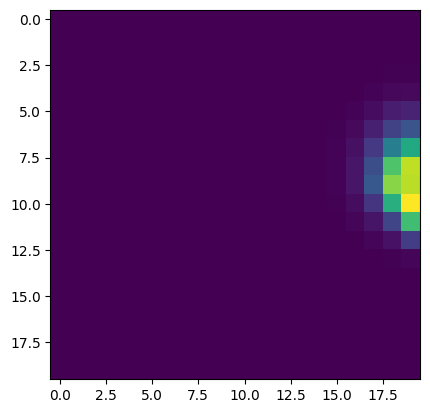

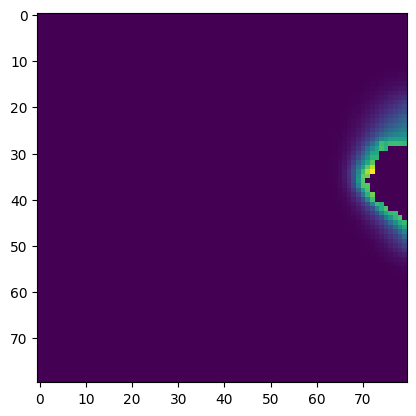

27 17 37
(20, 20)


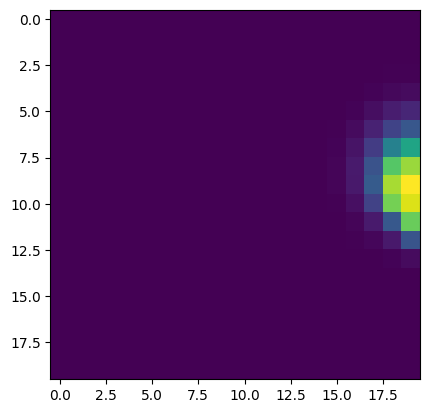

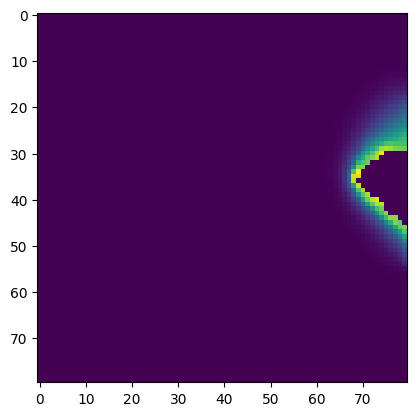

27 17 37
(20, 20)


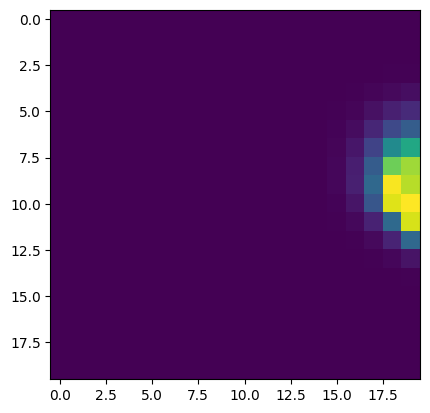

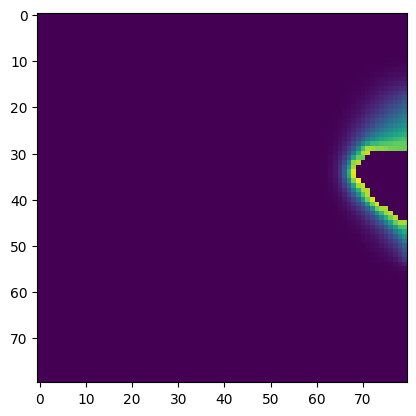

27 17 37
(20, 20)


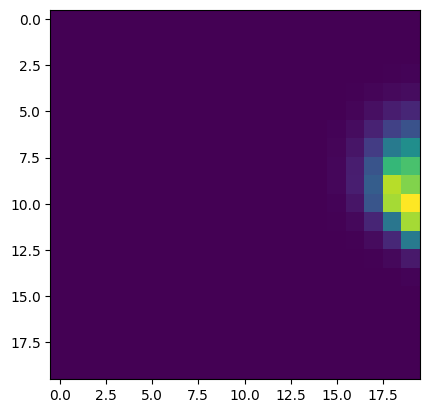

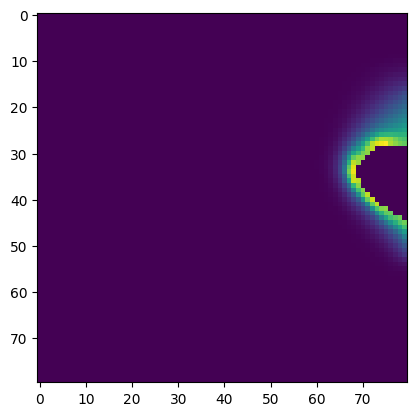

27 17 37
(20, 20)


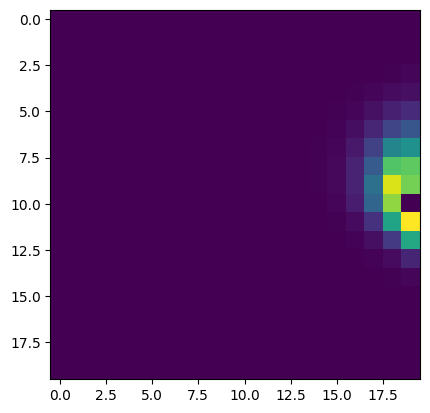

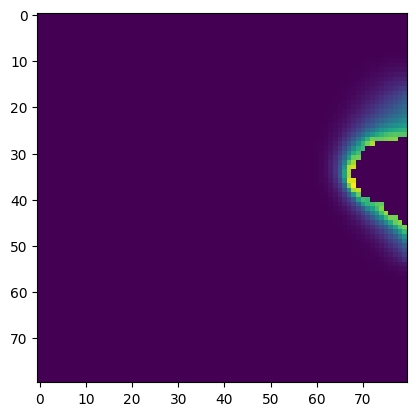

28 18 38
(20, 20)


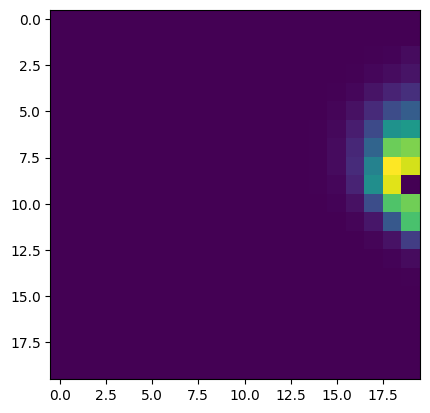

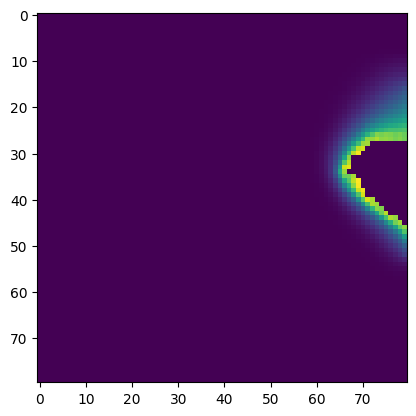

28 18 38
(20, 20)


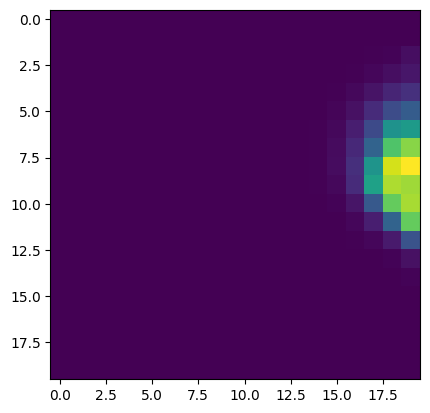

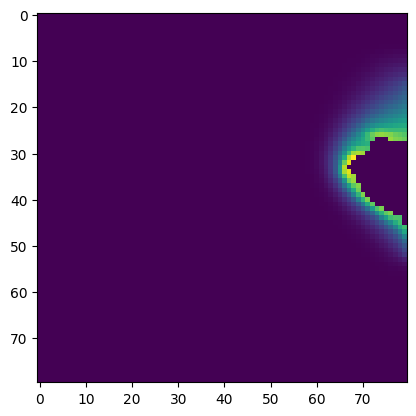

28 18 38
(20, 20)


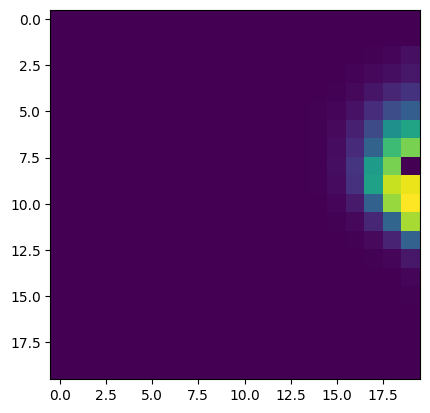

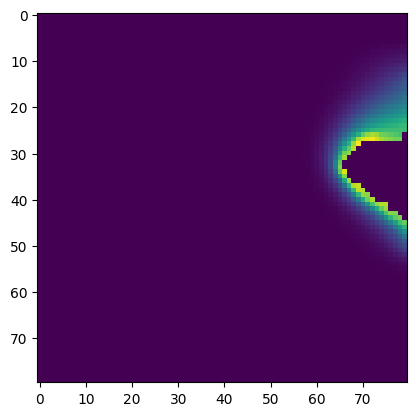

28 18 38
(20, 20)


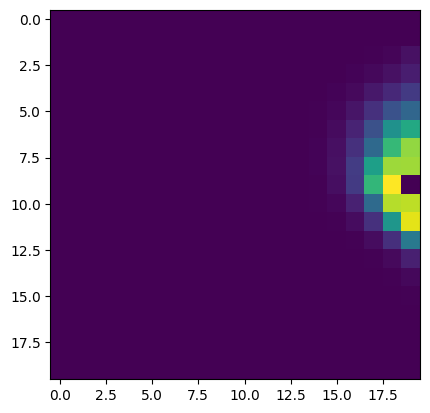

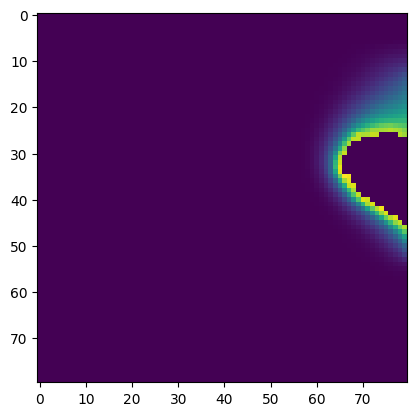

28 18 38
(20, 20)


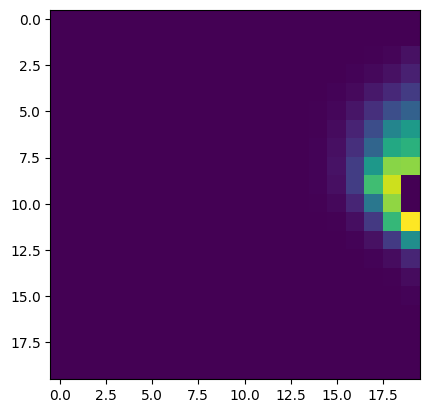

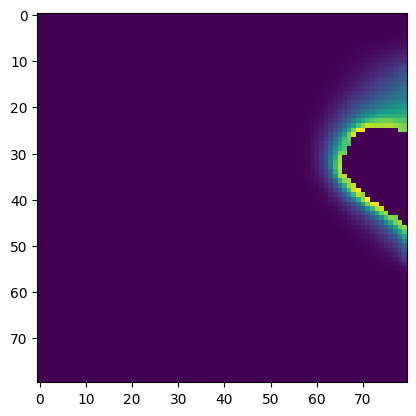

29 19 39
(20, 20)


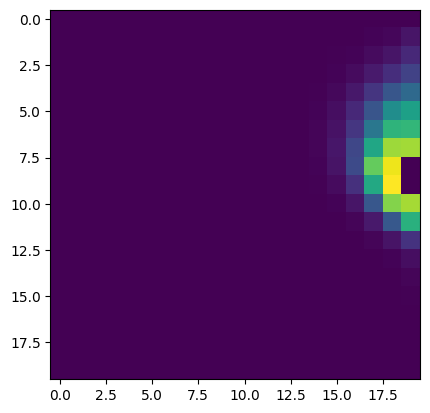

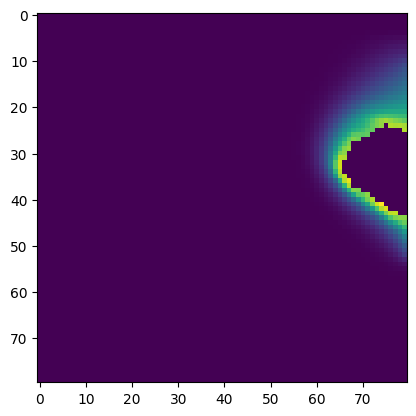

29 19 39
(20, 20)


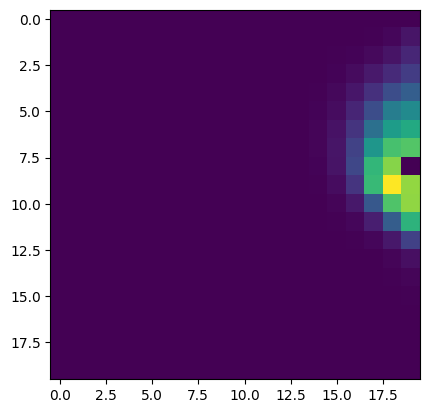

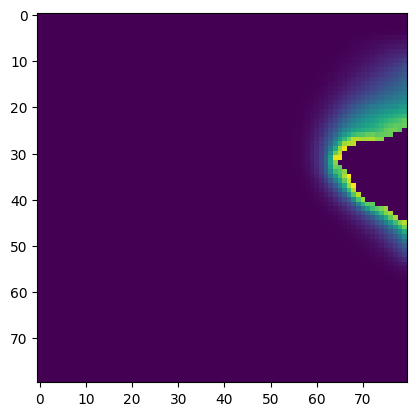

29 19 39
(20, 20)


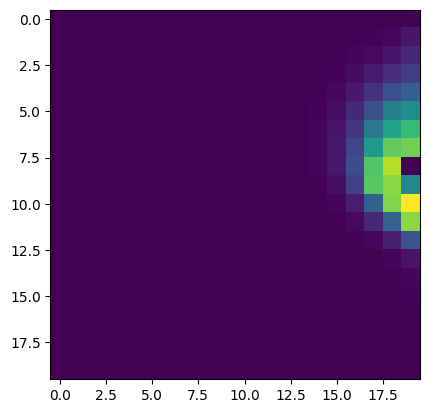

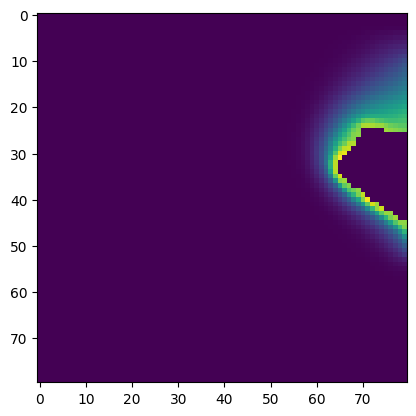

29 19 39
(20, 20)


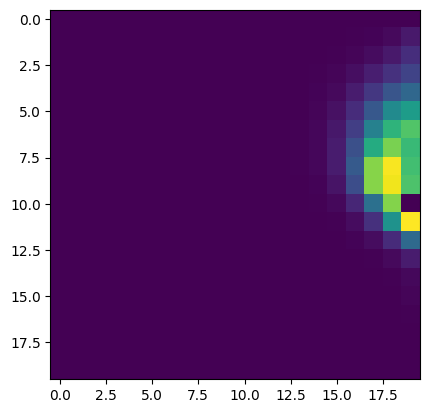

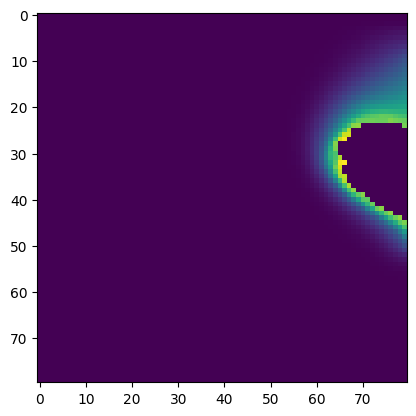

29 19 39
(20, 20)


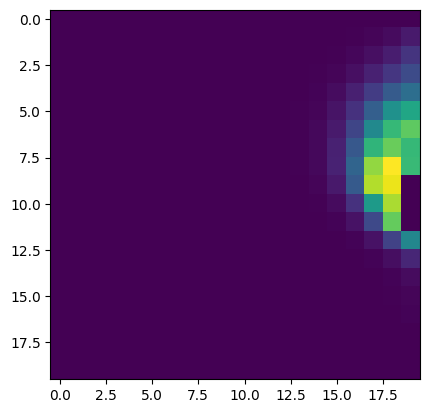

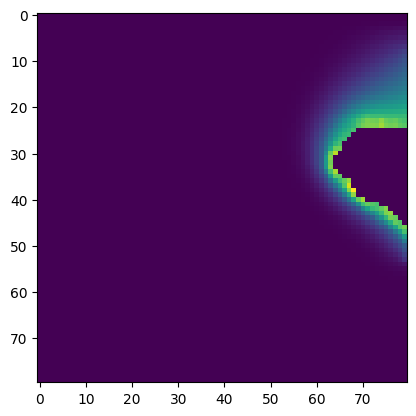

29 19 39
(20, 20)


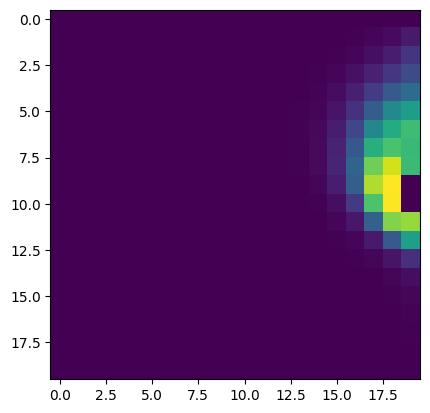

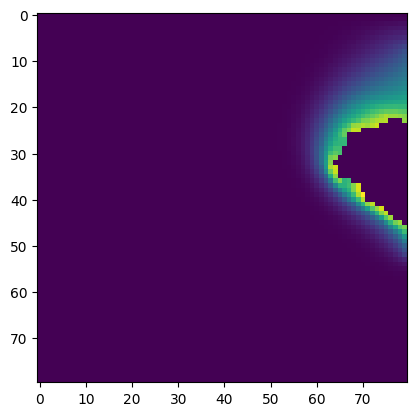

30 20 40
(20, 20)


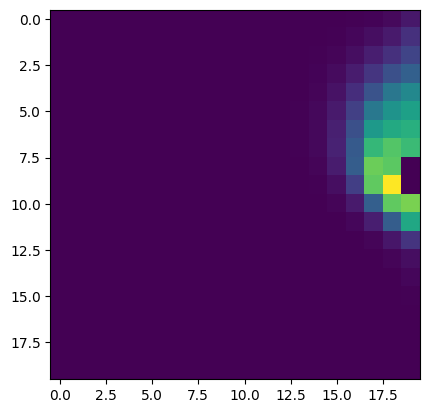

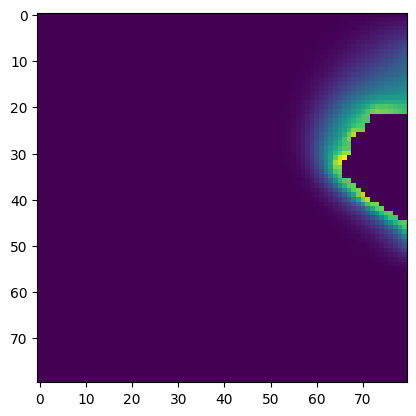

30 20 40
(20, 20)


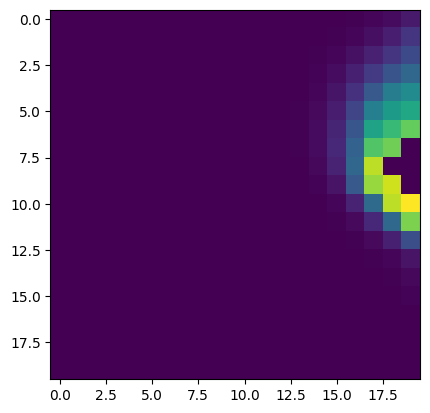

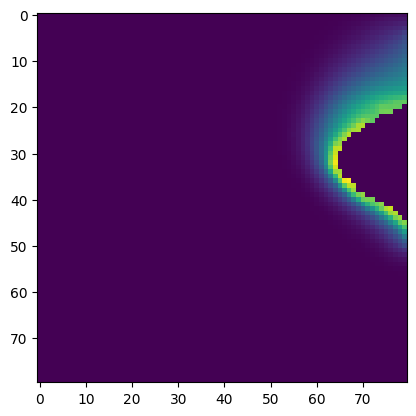

30 20 40
(20, 20)


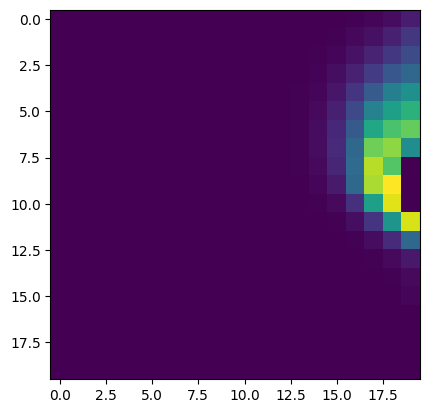

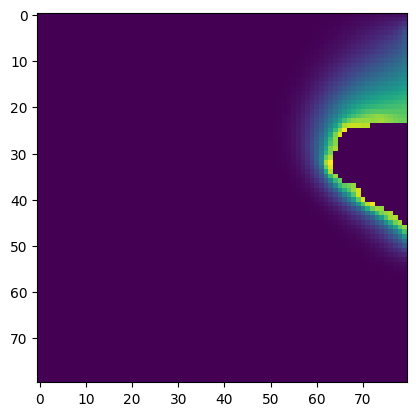

30 20 40
(20, 20)


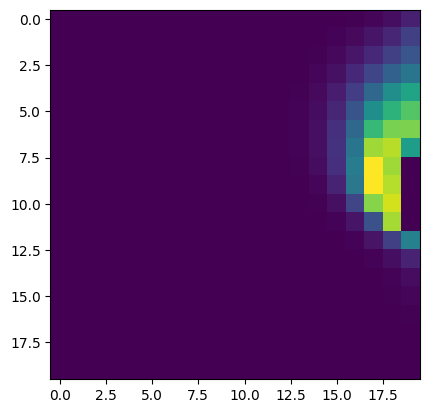

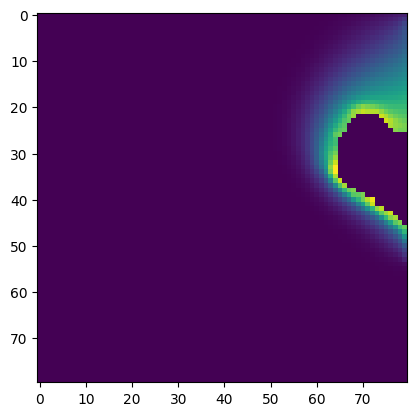

30 20 40
(20, 20)


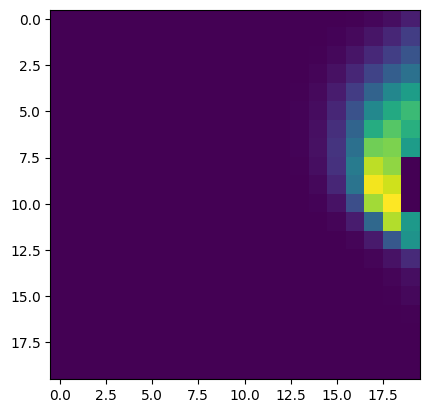

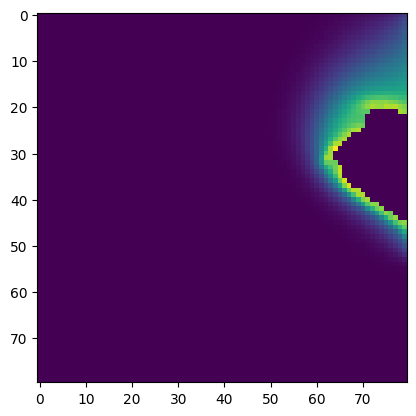

30 20 40
(20, 20)


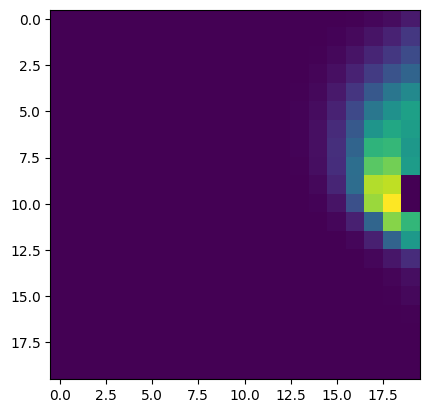

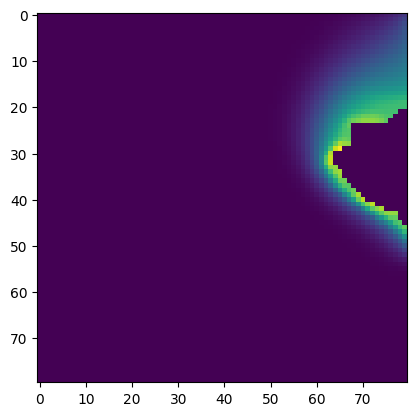

31 21 41
(20, 20)


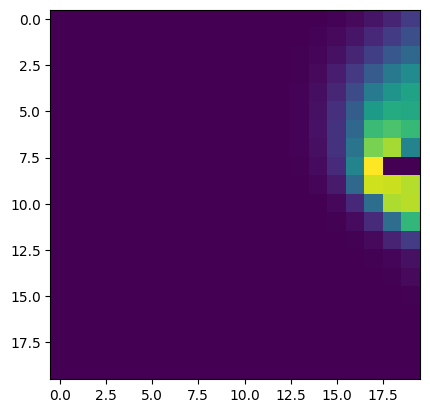

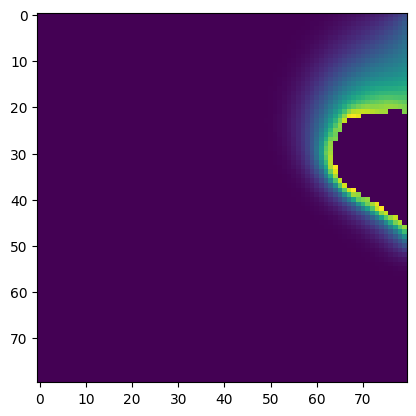

31 21 41
(20, 20)


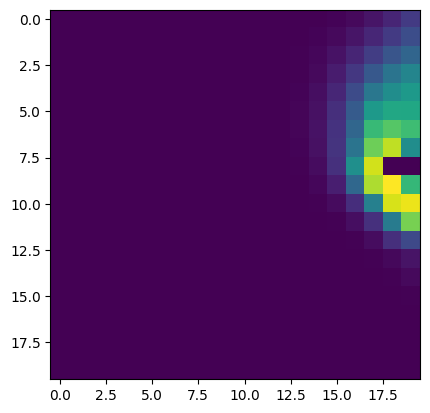

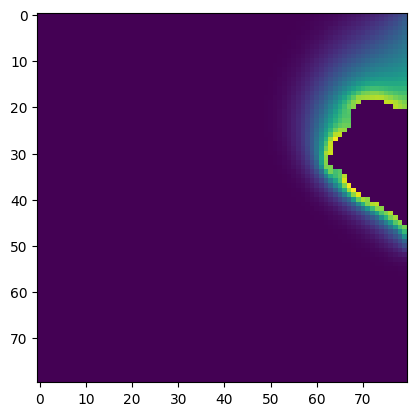

31 21 41
(20, 20)


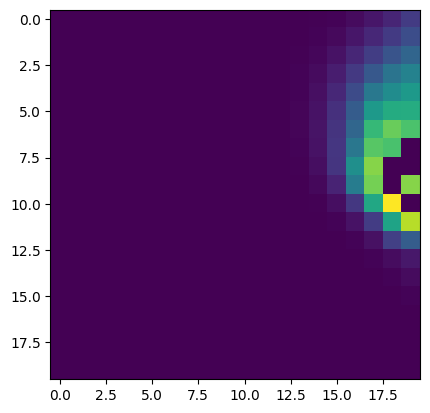

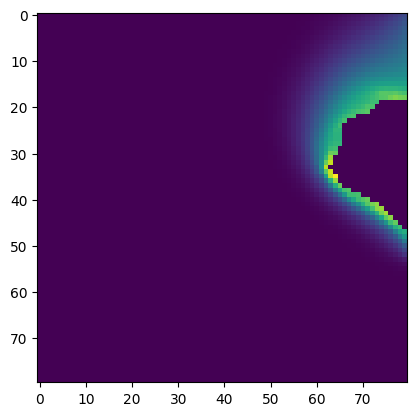

31 21 41
(20, 20)


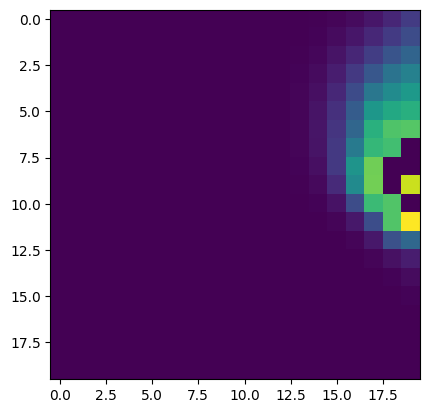

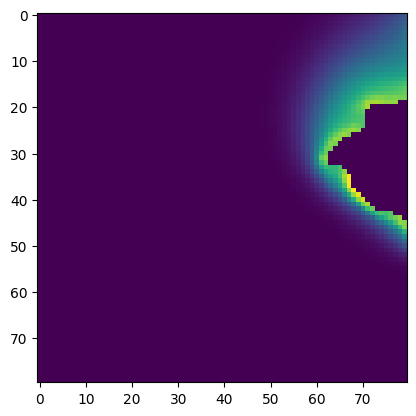

31 21 41
(20, 20)


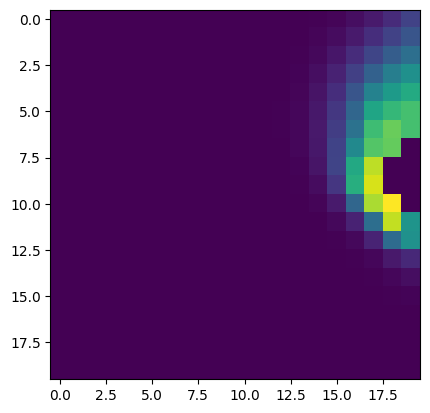

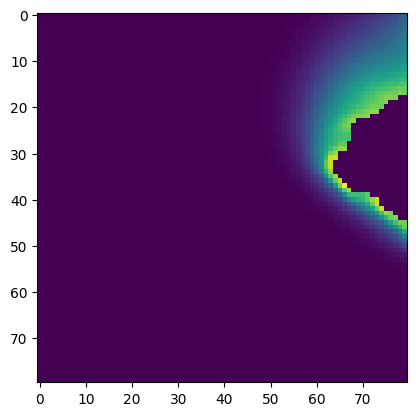

32 22 42
(20, 20)


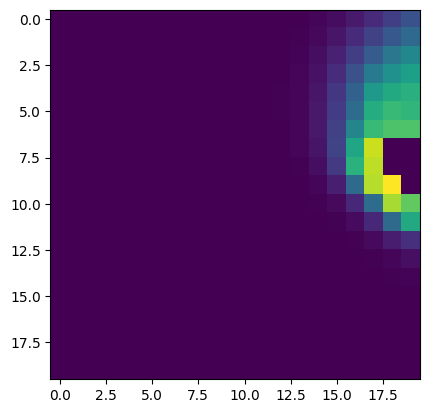

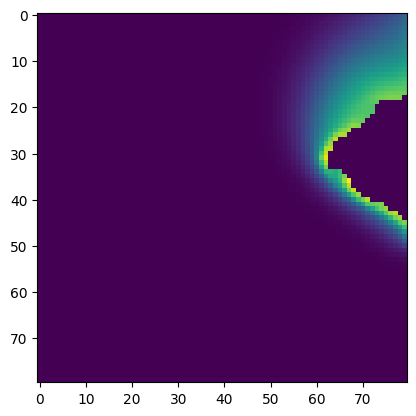

32 22 42
(20, 20)


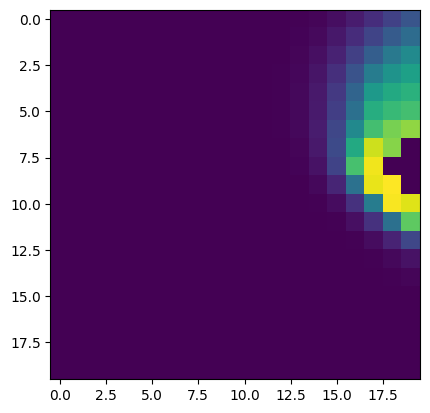

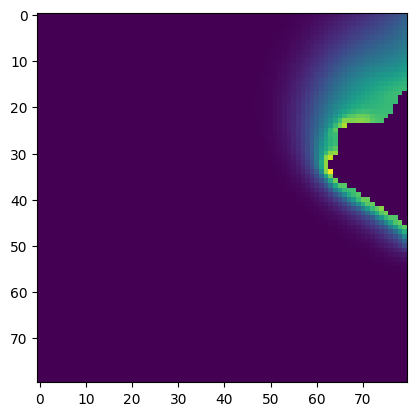

32 22 42
(20, 20)


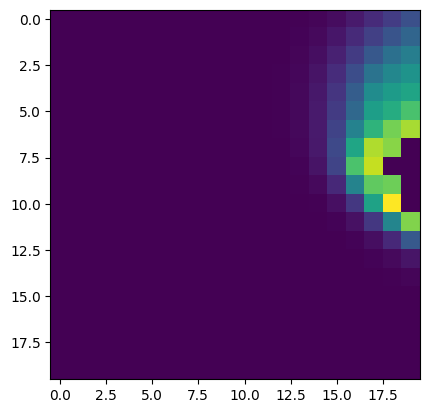

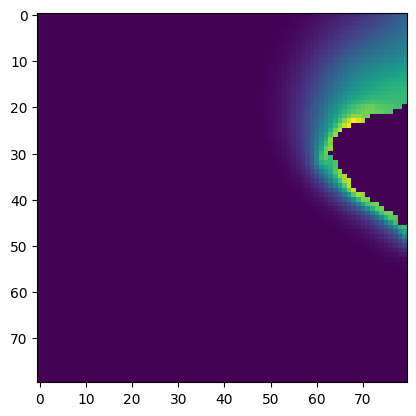

32 22 42
(20, 20)


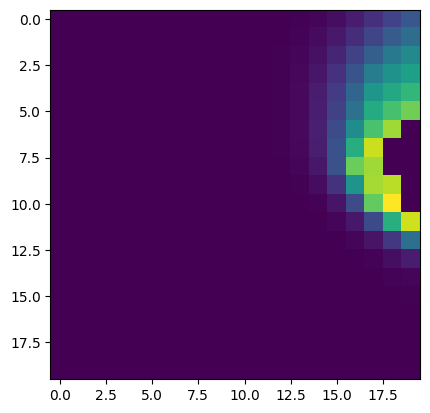

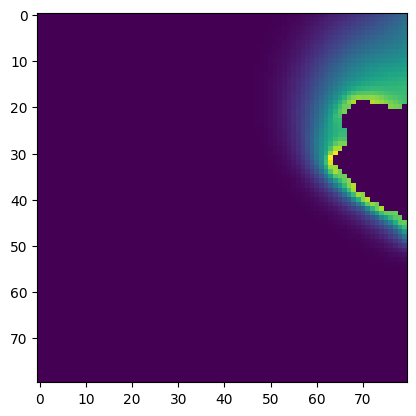

32 22 42
(20, 20)


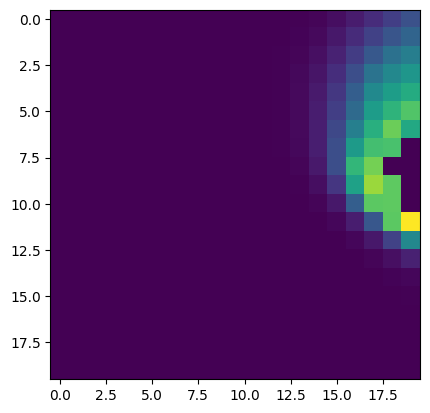

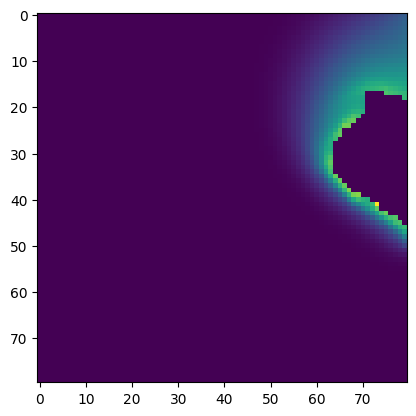

32 22 42
(20, 20)


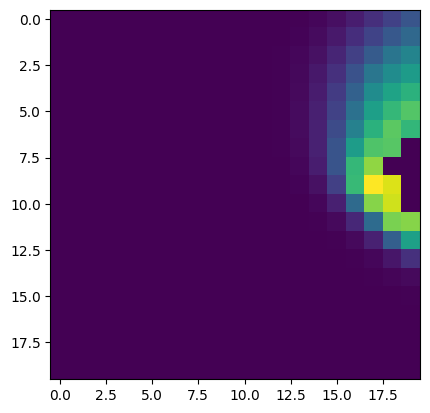

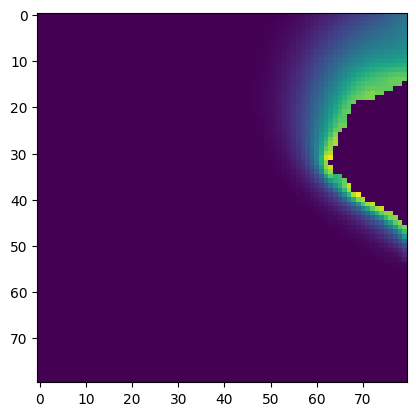

33 23 43
(20, 20)


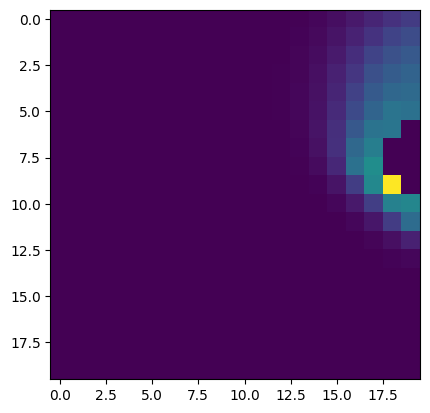

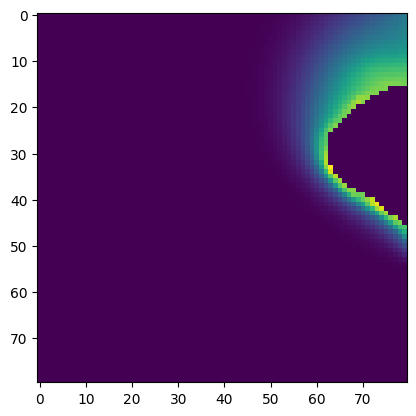

33 23 43
(20, 20)


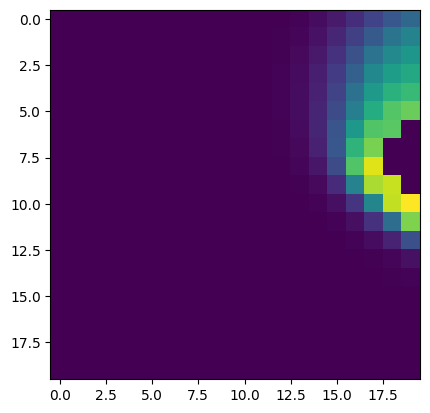

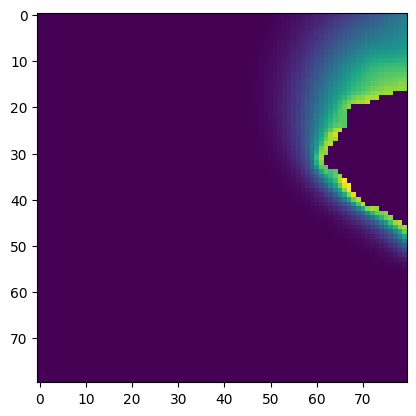

33 23 43
(20, 20)


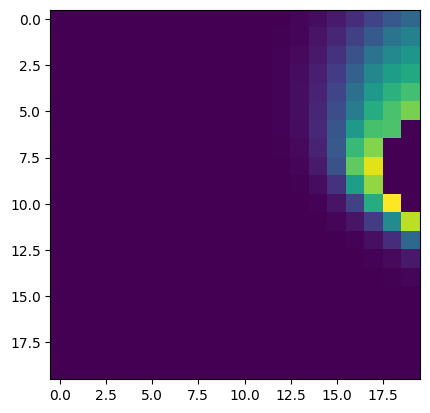

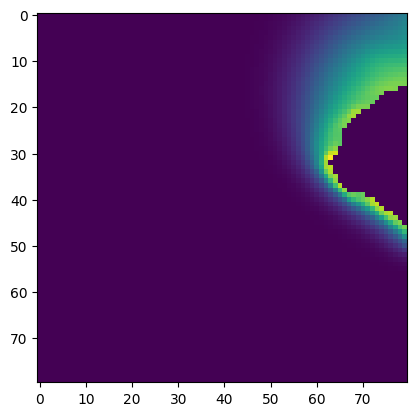

33 23 43
(20, 20)


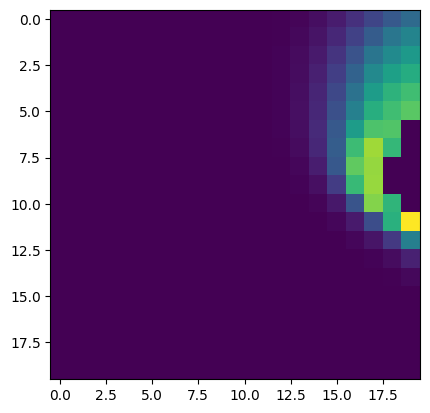

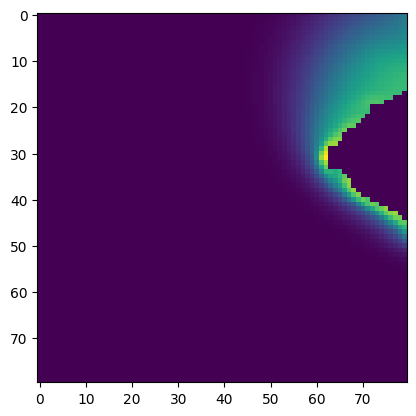

33 23 43
(20, 20)


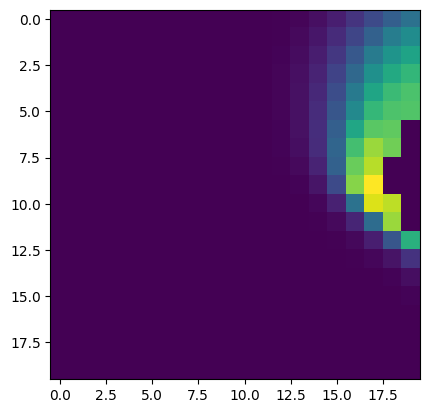

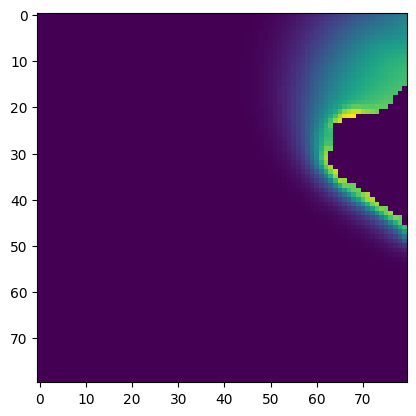

33 23 43
(20, 20)


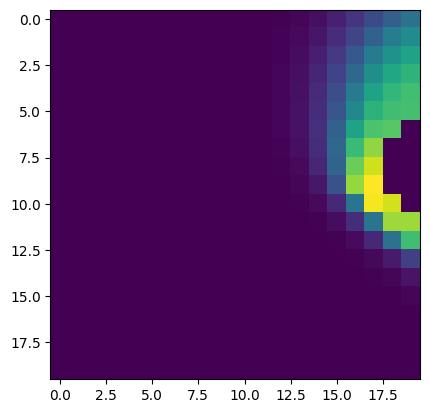

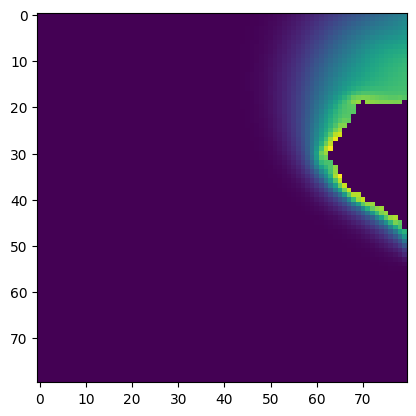

KeyboardInterrupt: 

In [136]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['axes.facecolor']='white'
plt.rcParams['savefig.facecolor']='white'

from skimage import transform
for i in range(2,100):
    tempframe = np.load('/home/oogoke/DiffusionSR/analysis/transfer_analysis/myoutput.melt_power_259_velocity_700_5micron/data{:02d}.npz'.format(i), allow_pickle=True)['temperature'][1:].astype('float')[:,60,:]

    lowrestempframe = np.load('/home/oogoke/DiffusionSR/analysis/transfer_analysis/myoutput.melt_power_259_velocity_700_20micron/data{:02d}.npz'.format(i), allow_pickle=True)['temperature'][1:].astype('float')[:,15,:]
    power = 259
    velocity = 700
    profiles = []
    img_size = 80
    padsize = img_size

    hres_point = 20 + (int(velocity)/1000)*(i-1)
    

    hr_theta_pad = np.copy(np.pad(tempframe, ((padsize, padsize), (0, 0)), mode = 'constant', constant_values = 293))
    lr_theta_pad = np.copy(np.pad(lowrestempframe, ((np.round(int(padsize/4)), np.round(int(padsize/4))), (0, 0)), mode = 'constant', constant_values = 293))

    idx_max = int(hres_point)  + padsize
    low_res_idx_max = int(20/4 + (5*int(velocity)/20/1000)*(i-1) + int(np.round(padsize/4)))

    lr_theta_cropped = lr_theta_pad[low_res_idx_max-10: low_res_idx_max+10, :20]
    print(low_res_idx_max, low_res_idx_max-10, low_res_idx_max+10)
    hr_theta_cropped = hr_theta_pad[int(np.round(idx_max))-40: int(np.round(idx_max))+40]
    plt.imshow(lr_theta_cropped)
    print(lr_theta_cropped.shape)
    plt.show()
    

    plt.imshow(hr_theta_cropped)
    plt.show()      

In [137]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['axes.facecolor']='white'
plt.rcParams['savefig.facecolor']='white'

from skimage import transform
def load_sample(index):

    # for i in range(2,100):
    tempframe = np.load('/home/oogoke/DiffusionSR/analysis/transfer_analysis/myoutput.melt_power_259_velocity_700_5micron/data{:02d}.npz'.format(index), allow_pickle=True)['temperature'][1:].astype('float')[:,60,:]

    lowrestempframe = np.load('/home/oogoke/DiffusionSR/analysis/transfer_analysis/myoutput.melt_power_259_velocity_700_20micron/data{:02d}.npz'.format(index), allow_pickle=True)['temperature'][1:].astype('float')[:,15,:]
    power = 259
    velocity = 700
    profiles = []
    img_size = 80
    padsize = img_size

    hres_point = 20 + (int(velocity)/1000)*(i-1)

    hr_theta_pad = np.copy(np.pad(tempframe, ((padsize, padsize), (0, 0)), mode = 'constant', constant_values = 293))
    lr_theta_pad = np.copy(np.pad(lowrestempframe, ((np.round(int(padsize/4)), np.round(int(padsize/4))), (0, 0)), mode = 'constant', constant_values = 293))

    idx_max = int(hres_point)  + padsize
    low_res_idx_max = int(20/4 + (5*int(velocity)/20/1000)*(i-1) + int(np.round(padsize/4)))
    lr_theta_cropped = lr_theta_pad[low_res_idx_max-10: low_res_idx_max+10, :20]
    # print(low_res_idx_max, low_res_idx_max-10, low_res_idx_max+10)
    hr_theta_cropped = hr_theta_pad[int(np.round(idx_max))-40: int(np.round(idx_max))+40]
        # plt.imshow(lr_theta_cropped)
        # print(lr_theta_cropped.shape)
        # plt.show()
        

        # plt.imshow(hr_theta_cropped)
        # plt.show()      
    return lr_theta_cropped, hr_theta_cropped

In [15]:
np.load('/home/oogoke/DiffusionSR/analysis/transfer_analysis/myoutput.melt_power_259_velocity_700_5micron/data96.npz', allow_pickle=True)['temperature'][1:].shape

(199, 120, 80)

In [39]:

device = 'cuda'


def compute_alpha(beta, t):
    beta = torch.cat([torch.zeros(1).to(beta.device), beta], dim=0).to(device)
    # print(beta.device, t.device)
    a = (1 - beta).cumprod(dim=0).index_select(0, t + 1).view(-1, 1, 1, 1)
    return a



def predict_modified_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, encoding, dataset, seq, timesteps = 200, skip = 1, schedule = 'linear', **kwargs):
    
    # skip =timesteps // self.args.timesteps
    seq = range(0, timesteps, skip)
    
    def cosine_beta_schedule(timesteps, s=0.008):

        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(
            ((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def linear_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start, beta_end, timesteps)


    def quadratic_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

    def sigmoid_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        betas = torch.linspace(-6, 6, timesteps)
        return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start
    if schedule == 'linear':
        betas = linear_beta_schedule(timesteps=timesteps)
    elif schedule == 'quadratic':
        betas = quadratic_beta_schedule(timesteps=timesteps)
    elif schedule == 'cosine':
        betas = cosine_beta_schedule(timesteps=timesteps)
    elif schedule == 'sigmoid':
        betas = sigmoid_beta_schedule(timesteps=timesteps)
    b = betas

    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)
    if encoding:
            # x_e = forwardpass(lr_enc, lr.to(device).float(), factor = train_dataset.factor)
        if len(lr.shape)< 4:
            x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float())
        else:
            x_e = forwardpass(lr_enc, lr.to(device).float())
    else:
        x_e = upscaled_lr.to(device).float().repeat(1,1,1, 1)
    shape=hr.shape
    with torch.no_grad():
        x = torch.randn(shape, device=device)
        n = x.size(0)
        seq_next = [-1] + list(seq[:-1])
        x0_preds = []
        xs = [x]
        for i, j in zip(reversed(seq), reversed(seq_next)):
            t = (torch.ones(n) * i).to(x.device)
            next_t = (torch.ones(n) * j).to(x.device)
            at = compute_alpha(b, t.long())
            at_next = compute_alpha(b, next_t.long())
            xt = xs[-1].to('cuda')
            et = model(xt, t, x_e)
            x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
            x0_preds.append(x0_t.to('cpu'))
            c1 = (
                kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
            )
            c2 = ((1 - at_next) - c1 ** 2).sqrt()
            xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
            xs.append(xt_next.to('cpu'))
    result = dataset.unscale_data(xs[-1], input_type = 'hr') 
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr'), xs, b





In [38]:


def predict_ss316l_ddim_diffusion(model, lr_enc, lr, encoding, dataset, timesteps = 200, skip = 1, schedule = 'linear', **kwargs):
    
    # skip =timesteps // self.args.timesteps
    seq = range(0, timesteps, skip)
    
    def cosine_beta_schedule(timesteps, s=0.008):

        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(
            ((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def linear_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start, beta_end, timesteps)


    def quadratic_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

    def sigmoid_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        betas = torch.linspace(-6, 6, timesteps)
        return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start
    if schedule == 'linear':
        betas = linear_beta_schedule(timesteps=timesteps)
    elif schedule == 'quadratic':
        betas = quadratic_beta_schedule(timesteps=timesteps)
    elif schedule == 'cosine':
        betas = cosine_beta_schedule(timesteps=timesteps)
    elif schedule == 'sigmoid':
        betas = sigmoid_beta_schedule(timesteps=timesteps)
    b = betas

    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        # target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        # target = hr.to(device)
    # if encoding:
            # x_e = forwardpass(lr_enc, lr.to(device).float(), factor = train_dataset.factor)
    if len(lr.shape)< 4:
        x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float())
    else:
        x_e = forwardpass(lr_enc, lr.to(device).float())
    # else:
        # x_e = upscaled_lr.to(device).float().repeat(1,1,1, 1)
    # shape=hr.shape
    with torch.no_grad():
        x = torch.randn((1,1, 80,80), device=device)
        n = x.size(0)
        seq_next = [-1] + list(seq[:-1])
        x0_preds = []
        xs = [x]
        for i, j in zip(reversed(seq), reversed(seq_next)):
            t = (torch.ones(n) * i).to(x.device)
            next_t = (torch.ones(n) * j).to(x.device)
            at = compute_alpha(b, t.long())
            at_next = compute_alpha(b, next_t.long())
            xt = xs[-1].to('cuda')
            et = model(xt, t, x_e)
            x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
            x0_preds.append(x0_t.to('cpu'))
            c1 = (
                kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
            )
            c2 = ((1 - at_next) - c1 ** 2).sqrt()
            xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
            xs.append(xt_next.to('cpu'))
    result = dataset.unscale_data(xs[-1], input_type = 'hr') 
    return dataset.unscale_data(lr, input_type='lr'), result#, dataset.unscale_data(target.cpu(), input_type = 'hr'), xs, b



In [41]:
class Simulation():
    def __init__(self, folder, diff_steps, schedule):
        self.folder = folder
        self.diff_steps = diff_steps
        self.schedule = schedule
        self.kp = None
        self.profile = None
        self.max_depth = None
        self.kp_depth = None
    def get_loss_curve(self):
        test_loss = np.loadtxt(os.path.join(self.folder, 'validation_loss_epoch.txt'))
        train_loss = np.loadtxt(os.path.join(self.folder, 'loss_epoch.txt'))
        return train_loss, test_loss


In [32]:
diffusion_results_dir = '/home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_02_26_02_05_27/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/diffusionexplicitencoded/2023_02_15_11_20_16/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/diffusionexplicitencoded/2023_02_15_11_20_16/standardize/n_steps_1'
encoder_results_dir = '/home/oogoke/DiffusionSR/runs/direct/encoder/2023_02_26_02_05_27/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/encoder/2023_02_14_20_37_48/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/encoder/2023_02_14_20_37_48/standardize/n_steps_1'
timesteps = 1000
conditioning = 'implicit'
encoding = 'True'
schedule = 'linear'
device= 'cuda'
encode_bool = encoding == 'True'

os.environ['CUDA_VISIBLE_DEVICES']  = "0"
batch_size = 1
downscale_method = 'direct'
analysis_folder = f'analyzed_figures_paper_3_20/{timesteps}_{conditioning}_{schedule}_{downscale_method}'
os.makedirs( analysis_folder, exist_ok = True)

data_folder = '/home/oogoke/DiffusionSR/datasets/simulation_basis_v3_laser_velocity_xz_cross_section_data'#'/home/oogoke/DiffusionSR/datasets/update_v2_laser_velocity_xz_cross_section_data'#'/home/oogoke/DiffusionSR/datasets/simulation_basis_laser_velocity_xz_cross_section_data'
train_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'train', root_folder = data_folder , return_info = True)
test_dataset = SimulationXZDataset(downscale_method ='direct', split = 'test', root_folder = data_folder, return_info = True)
dev_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'dev', root_folder = data_folder, return_info = True)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=1, shuffle=False, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=True)


Using normalize method: ... standardize
Using all 1 fields
Processing dataset with 1 fields
Using normalize method: ... standardize
Using all 1 fields
Processing dataset with 1 fields
Using normalize method: ... standardize
Using all 1 fields
Processing dataset with 1 fields


In [33]:
ss316l_data =  SimulationXZDataset(downscale_method = 'direct', split = 'train', root_folder = '/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data' , return_info = True, field_names = ['temperature'])
ss316l_data.img_shape = 40

Using normalize method: ... standardize
Using specific fields,  ['temperature']
Processing dataset with 1 fields


In [48]:
ss316l_dataloader = DataLoader(ss316l_data, batch_size=batch_size, shuffle=False, drop_last=True)


In [47]:
ss316l_data.stats_path = os.path.join(
    train_dataset.root_folder, 'statistics', ss316l_data.downscale_method)
ss316l_data.std_lr = np.load(os.path.join(
    train_dataset.stats_path, 'std_lr.npy'))
ss316l_data.mean_lr = np.load(os.path.join(
    train_dataset.stats_path, 'mean_lr.npy'))
ss316l_data.std_resid = np.load(os.path.join(
    ss316l_data.stats_path, 'std_resid.npy'))
ss316l_data.mean_resid = np.load(os.path.join(
    ss316l_data.stats_path, 'mean_resid.npy'))
ss316l_data.std_hr = np.load(os.path.join(
    ss316l_data.stats_path, 'std_hr.npy'))
ss316l_data.mean_hr = np.load(os.path.join(
    ss316l_data.stats_path, 'mean_hr.npy'))
ss316l_data.std_upscaled_lr = np.load(os.path.join(
    ss316l_data.stats_path, 'std_upscaled_lr.npy'))
ss316l_data.mean_upscaled_lr = np.load(os.path.join(
    ss316l_data.stats_path, 'mean_upscaled_lr.npy'))

/home/oogoke/DiffusionSR/datasets/dataset.py:410: RuntimeWarning: divide by zero encountered in true_divide
  true_lr = (true_lr - self.mean_lr)/self.std_lr
/home/oogoke/DiffusionSR/datasets/dataset.py:410: RuntimeWarning: invalid value encountered in true_divide
  true_lr = (true_lr - self.mean_lr)/self.std_lr


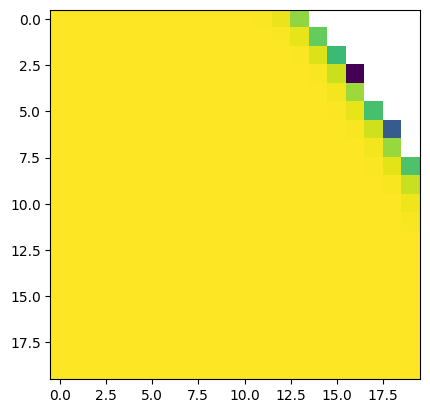

In [78]:
plt.imshow(ss316l_data[0][2][0].T)#.shape

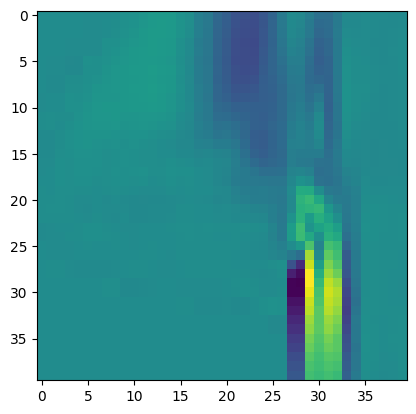

In [69]:
# plt.imshow(ss316l_data[0][0][0])

In [42]:
from runners.train_diffusion import DiffusionModel

def initialize_diffusion(diff_dir, enc_dir, datasets, timesteps, conditioning, encoding, schedule, device):
    ''' 
    Parameters:
        diff_dir: (str) Diffusion results directory
        enc_dir: (str) Encoder results directory
        datasets: (tuple or list) The three dataset objects corresponding to the train/validation/test splits, in the order (train, validation, test).
        timesteps: (int) The number of timesteps used for the diffusion model during training
        conditioning: (boolean) If true, the diffusion model assumes the LR passes through an encoder before being used for conditioning
        schedule: (str) Variance schedule used for training the diffusion model
        device: (str) 'cuda' for GPU, 'cpu' for CPU.
    Returns:
        diffusion_model: Custom DiffusionModel object that enables sampling with either DDIM or DDPM samplers.
    '''

    diffusion_model = DiffusionModel(results_folder=diff_dir,
                                    lr_encoder_folder=enc_dir,
                                    train_dataset=datasets[0],
                                    dev_dataset=datasets[1],
                                    test_dataset=datasets[2],
                                    timesteps=timesteps,
                                    conditioning=conditioning,
                                    encoding=encoding,
                                    schedule=schedule,
                                    device=device,enc_output = False
                                    )
    diffusion_model.load_saved_model()
    return diffusion_model

diff_model = initialize_diffusion(diff_dir=diffusion_results_dir,
                                  enc_dir=encoder_results_dir,
                                  datasets=[train_dataset,
                                            dev_dataset, test_dataset],
                                  timesteps=timesteps,
                                  conditioning=conditioning,
                                  encoding=encoding,
                                  schedule=schedule,
                                  device=device)


lr_enc = load_encoder(encoder_results_dir, dataset = train_dataset)


Loading encoder ... encoding = True
TIMESTEPS == 1000, Schedule = linear
Loading model from /home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_02_26_02_05_27/standardize/n_steps_1
model found, loading


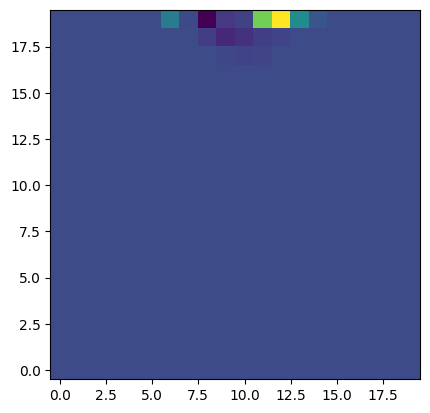

In [127]:
# file = np.load('/home/oogoke/DiffusionSR/datasets/ss316l_v2_all_laser_velocity_xz_cross_section_data/train/LR/direct/1x/power100velocity100_1032.npy')
# plt.imshow(np.roll(file[:,:,0].T,(4), axis = 0), origin = 'lower')

In [94]:
def predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, dataset, skip = 50):

    '''
    Return the predictions for the Diffusion model given an input batch
    Parameters:
    diff_model: DiffusionModel object
    lr_enc: Torch network module object, representing the trained RRDN encoder model
    res: Torch tensor, Residual between HR and LR data
    hr: Torch tensor, High Resolution data
    lr: Torch tensor, Low Resolution data
    upscaled_lr: Torch tensor, Bicubic upscaled low resolution data
    dataset: Dataset object, used for rescaling data
    Returns:
    Low resolution data, scaled to original space, 4-D numpy array (batch, channels, height, width)
    Output (Super-resolution), scaled to original space, 4-D numpy array
    High resolution data, scaled to original space, 4-D numpy array 
    '''

    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)
    if len(lr.shape) < 4:

        x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float(), factor = dataset.factor)
    else:
        x_e = forwardpass(lr_enc, lr.to(device).float(), factor = dataset.factor)
        x_e = forwardpass(lr_enc, lr.to(device).float())
        all_images = diff_model.batch_sample(dataset = train_dataset, batch = hr, x_e = x_e, sampler = 'DDIM', skip= skip)                
        result = dataset.unscale_data(all_images.cpu().numpy()[-1, 0], input_type = 'residual') + dataset.unscale_data(upscaled_lr.numpy(), input_type = 'upscaled_lr')
        
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr')
skip = 30
for batch_idx, (res, hr, lr, upscaled_lr, info) in enumerate(train_dataloader):            
    #input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, train_dataloader.dataset)
    input, result_diffusion, target, _, _ = predict_modified_ddim_diffusion(diff_model.model, lr_enc, res, hr, lr, upscaled_lr,encoding = encode_bool,dataset =  train_dataset,seq= None, timesteps = timesteps,skip = skip, schedule = 'linear')
    break


In [101]:
# ss316l_data[1][2].reshape(1,1,20,20)


(1, 1, 20, 20)

In [95]:
input, result_diffusion, target, _, _ = predict_modified_ddim_diffusion(diff_model.model, lr_enc, res, hr, lr, upscaled_lr,encoding = encode_bool,dataset =  train_dataset,seq= None, timesteps = timesteps,skip = skip, schedule = 'linear')


In [63]:
file = np.load('/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data/test/LR/direct/1x/power490velocity1350/_1090.npy')#np.load('/home/oogoke/DiffusionSR/datasets/ss316l_v2_all_laser_velocity_xz_cross_section_data/train/LR/direct/1x/power490velocity450/_1032.npy')
inp_sample = np.roll(file[:,:,1],(4), axis = 1)#.T, origin = 'lower'


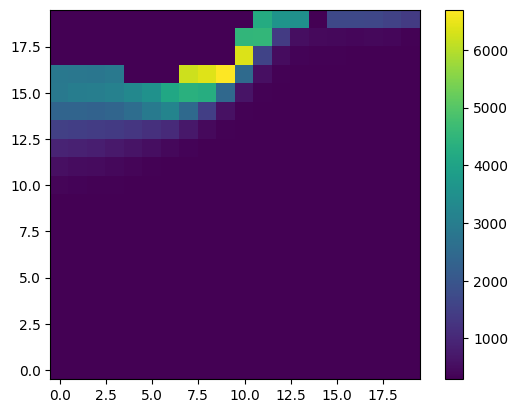

In [64]:
# inp_sample.shape
plt.imshow(torch.Tensor(inp_sample).reshape(1,1,20,20)[0][0].numpy().T, origin = 'lower')
plt.colorbar()

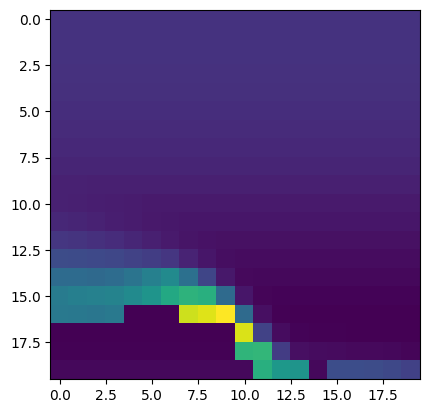

In [65]:
plt.imshow(ss316l_data.rescale_data(torch.Tensor(inp_sample).reshape(1,1,20,20), input_type = 'lr')[0][0].numpy().T)
# plt.colorbar()

In [98]:
ss316l_lr.shape

(50, 0)

In [97]:
input, result_diffusion = predict_ss316l_ddim_diffusion(model = diff_model.model, lr_enc = lr_enc, lr = ss316l_data.rescale_data(torch.Tensor(ss316l_lr).reshape(1,1,20,20), input_type = 'lr'), encoding = 'True', dataset = train_dataloader.dataset)

RuntimeError: shape '[1, 1, 20, 20]' is invalid for input of size 0

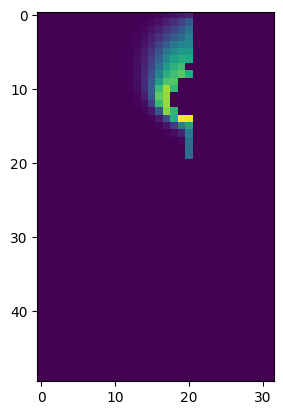

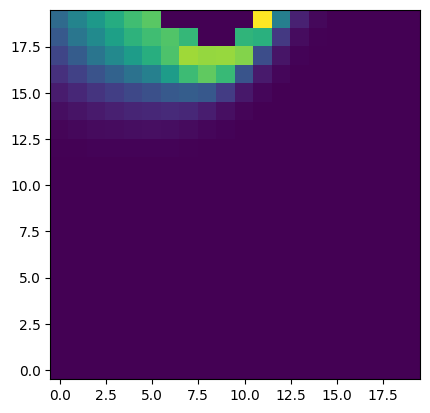

(20, 20)


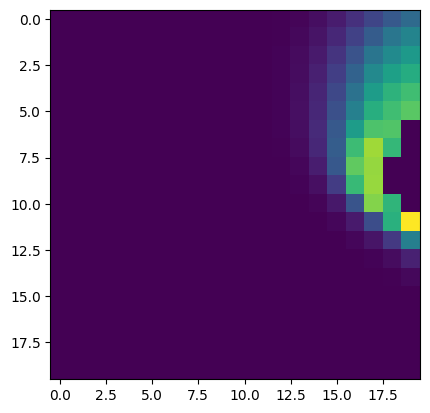

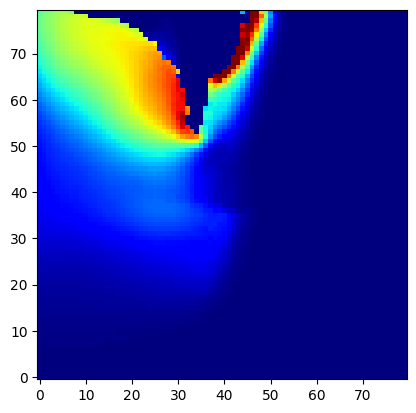

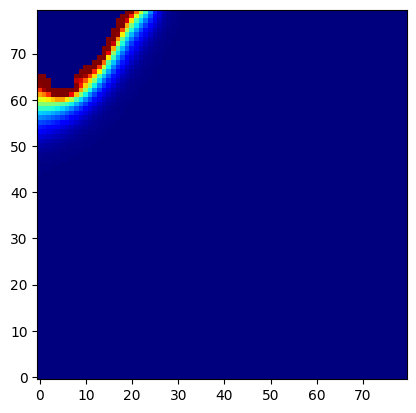

In [121]:
# result_diffusion.shape
plt.imshow(cross_20)
plt.show()
ss316l_lr = cross_20[3:23, :20]
plt.imshow(ss316l_lr.T, origin = 'lower')
plt.show()
print(ss316l_lr.shape)
# for i in range(2,100):
    # cross_5 = np.load('/home/oogoke/DiffusionSR/analysis/transfer_analysis/myoutput.melt_power_259_velocity_700_5micron/data{:02d}.npz'.format(i), allow_pickle=True)['temperature'][1:].astype('float')[:,60,:]
    # cross_20 = np.load('/home/oogoke/DiffusionSR/analysis/transfer_analysis/myoutput.melt_power_259_velocity_700_20micron/data{:02d}.npz'.format(i), allow_pickle=True)['temperature'][1:].astype('float')[:,15,:]
input, result_diffusion = predict_ss316l_ddim_diffusion(model = diff_model.model, lr_enc = lr_enc, lr = ss316l_data.rescale_data(torch.Tensor(ss316l_lr).reshape(1,1,20,20), input_type = 'lr'), encoding = 'True', dataset = train_dataloader.dataset)
plt.imshow(ss316l_lr)
plt.show()
plt.imshow(result_diffusion[0][0].cpu().numpy().T, origin = 'lower', cmap  = 'jet', vmin = 293, vmax = 3500)
plt.show()
plt.imshow(cross_5[40:120, 0:80].T, origin = 'lower', cmap  = 'jet', vmin = 293, vmax = 3500)
plt.show()


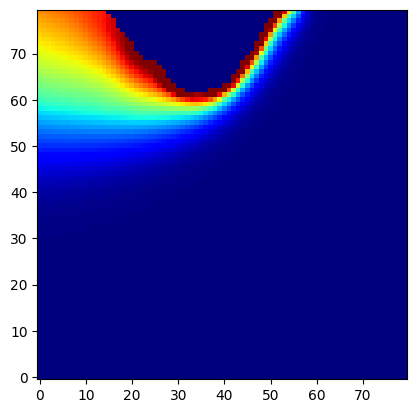

In [135]:
for batch_idx, (res, hr, lr, upscaled_lr, info) in enumerate(ss316l_dataloader):            
    #input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, train_dataloader.dataset)
    ss316l_dataloader.dataset.img_shape = 40
    # input, result_diffusion, target, _, _ = predict_modified_ddim_diffusion(diff_model.model, lr_enc, res, hr, lr, upscaled_lr,encoding = encode_bool,dataset =  train_dataset,seq= None, timesteps = timesteps,skip = skip, schedule = 'linear')
    predict_ss316l_ddim_diffusion(model = diff_model.model, lr_enc = lr_enc, lr = lr, encoding = "True", dataset = ss316l_dataloader.dataset)
    break


ValueError: operands could not be broadcast together with shapes (6,40,40) (80,80) 

In [10]:
last_power = ''
modeltype = 'Diffusion' # Defines part of the title of the image

# diff_results_global = {}
skip = 50
for trial_key in range(10):
    enc_depths_sim = []
    # diff_depths_sim = []
    gt_depths_sim = []
    lr_depths_sim = []
    # enc_kp_sim = []
    # diff_kp_sim = []
    gt_kp_sim = []
    lr_kp_sim = []
    gt_results = {}
    # enc_results = {}
    # diff_results = {}
    lr_results = {}
    for batch_idx, (res, hr, lr, upscaled_lr, info) in tqdm(enumerate(train_dataloader), total = len(train_dataloader)):  
    

        oldtime = time.time()

        input, result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
        # input, result_diffusion, target, _, _ = predict_modified_ddim_diffusion(diff_model.model, lr_enc, res, hr, lr, upscaled_lr,encoding = encode_bool,dataset =  train_dataset,seq= None, timesteps = timesteps,skip = skip, schedule = 'linear')
        # input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, dev_dataloader.dataset)
        # input, result_diffusion, target = predict_modified_diffusion(diff_model.model, lr_enc, res, hr, lr, upscaled_lr,dataset =  train_dataset, timesteps = timesteps, schedule = 'linear')
        
        info = info[0] # info is technically returned with an extra dimension, this command removes it.
        time_elapsed = time.time()-oldtime
        # print(last_power)
        if last_power != 'power' + str(info[0].item()) + 'vel' + str(info[1].item()):
            
            timestep = 0

            # enc_depths_sim = []
            # diff_depths_sim = []
            gt_depths_sim = []
            lr_depths_sim = []
            # enc_kp_sim = []
            # diff_kp_sim = []
            gt_kp_sim = []
            lr_kp_sim = []

        else:
            timestep += 1
        # profile_diff, kp_diff = get_profile(result_diffusion[0])
        profile_gt, kp_gt = get_profile(target[0])
        # profile_enc, kp_enc = get_profile(result[0])
        profile_lr, kp_lr = get_profile(input[0])

        # enc_kp_sim.append(5*(80-np.min(kp_enc)))
        gt_kp_sim.append(5*(80-np.min(kp_gt)))
        # diff_kp_sim.append(5*(80-np.min(kp_diff)))
        lr_kp_sim.append(20*(20 - np.min(kp_lr)))
        # enc_depths_sim.append(5*(80-np.min(profile_enc)))
        gt_depths_sim.append(5*(80-np.min(profile_gt)))
        # diff_depths_sim.append(5*(80-np.min(profile_diff)))
        lr_depths_sim.append(20*(20 - np.min(profile_lr)))
        if lr_depths_sim[-1] < 50 and gt_depths_sim[-1] > 100:
           continue
        last_power = 'power' + str(info[0].item()) + 'vel' + str(info[1].item())  
        gt_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = gt_kp_sim
        # enc_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = enc_kp_sim
        # diff_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = diff_kp_sim
        lr_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item())] = lr_kp_sim
        gt_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = gt_depths_sim
        # enc_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = enc_depths_sim
        # diff_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = diff_depths_sim
        lr_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item())] = lr_depths_sim
    # diff_results_global[trial_key] = diff_results
        # if batch_idx > 3:
        #     break
    break

100%|██████████| 2970/2970 [00:44<00:00, 66.45it/s]


In [26]:
last_power = ''
modeltype = 'Diffusion' # Defines part of the title of the image

# test_diff_results_global = {}
skip = 50
for trial_key in range(10):
    test_enc_depths_sim = []
    test_diff_depths_sim = []
    test_gt_depths_sim = []
    test_lr_depths_sim = []
    test_enc_kp_sim = []
    test_diff_kp_sim = []
    test_gt_kp_sim = []
    test_lr_kp_sim = []
    test_gt_results = {}
    test_enc_results = {}
    test_diff_results = {}
    test_lr_results = {}
    for batch_idx, (res, hr, lr, upscaled_lr, info) in tqdm(enumerate(test_dataloader), total = len(test_dataloader)):  
    

        oldtime = time.time()

        input, result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
        # input, result_diffusion, target, _, _ = predict_modified_ddim_diffusion(diff_model.model, lr_enc, res, hr, lr, upscaled_lr,encoding = encode_bool,dataset =  train_dataset,seq= None, timesteps = timesteps,skip = skip, schedule = 'linear')
        # input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, dev_dataloader.dataset)
        # input, result_diffusion, target = predict_modified_diffusion(diff_model.model, lr_enc, res, hr, lr, upscaled_lr,dataset =  train_dataset, timesteps = timesteps, schedule = 'linear')
        
        info = info[0] # info is technically returned with an extra dimension, this command removes it.
        time_elapsed = time.time()-oldtime
        # print(last_power)
        if last_power != 'power' + str(info[0].item()) + 'vel' + str(info[1].item()):
            
            timestep = 0

            # test_enc_depths_sim = []
            test_diff_depths_sim = []
            test_gt_depths_sim = []
            test_lr_depths_sim = []
            # test_enc_kp_sim = []
            test_diff_kp_sim = []
            test_gt_kp_sim = []
            test_lr_kp_sim = []

        else:
            timestep += 1
        # profile_diff, kp_diff = get_profile(result_diffusion[0])
        profile_gt, kp_gt = get_profile(target[0])
        # profile_enc, kp_enc = get_profile(result[0])
        profile_lr, kp_lr = get_profile(input[0])

        # test_enc_kp_sim.append(5*(80-np.min(kp_enc)))
        test_gt_kp_sim.append(5*(80-np.min(kp_gt)))
        # test_diff_kp_sim.append(5*(80-np.min(kp_diff)))
        test_lr_kp_sim.append(20*(20 - np.min(kp_lr)))

        # test_enc_depths_sim.append(5*(80-np.min(profile_enc)))
        test_gt_depths_sim.append(5*(80-np.min(profile_gt)))
        # test_diff_depths_sim.append(5*(80-np.min(profile_diff)))
        test_lr_depths_sim.append(20*(20 - np.min(profile_lr)))
        last_power = 'power' + str(info[0].item()) + 'vel' + str(info[1].item())  
        test_gt_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = test_gt_kp_sim
        # test_enc_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = test_enc_kp_sim
        # test_diff_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = test_diff_kp_sim
        test_lr_results['key_power' + str(info[0].item()) + 'vel' + str(info[1].item())] = test_lr_kp_sim
        test_gt_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = test_gt_depths_sim
        # test_enc_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = test_enc_depths_sim
        # test_diff_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item()) ] = test_diff_depths_sim
        test_lr_results['depth_power' + str(info[0].item()) + 'vel' + str(info[1].item())] = test_lr_depths_sim
    # test_diff_results_global[trial_key] = test_diff_results
        # if batch_idx > 3:
        #     break
    break

100%|██████████| 693/693 [00:11<00:00, 60.95it/s]


In [19]:
# lr_results.keys()
diff_results_global[0]

{'key_power106.0vel700.0': [5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  10,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  10,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  5,
  10,
  5,
  5,
  5,
  5],
 'depth_power106.0vel700.0': [10,
  10,
  10,
  10,
  15,
  15,
  15,
  15,
  15,
  15,
  15,
  20,
  20,
  15,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  15,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  20,
  2

In [64]:
gt_kps = []
enc_kps = []
lr_kps = []
diff_kps = []
diff_kps_std = []

gt_mps = []
enc_mps = []
diff_mps = []
diff_mpstd = []
j = 79
lr_mps = []
kp_powers =[]
kp_velocities = []
mp_powers =[]
mp_velocities = []
for key in lr_results.keys():
    print(key, gt_results.keys())
    if 'depth' in key:
        parameters = key.split('depth_power')[-1].split('vel')
        mp_powers.append(float(parameters[0]))
        mp_velocities.append(float(parameters[1]))
        gt_mp = gt_results[key][j]
        
        diff_mp_mean = np.mean([diff_results_global[trial_key][key][j] for trial_key in range(len(diff_results_global.keys()))])
        diff_mp_std = np.std([diff_results_global[trial_key][key][j] for trial_key in range(len(diff_results_global.keys()))])

        # enc_mp  = enc_results[key][-1]
        lr_mp =  lr_results[key][j]
        lr_mps.append(lr_mp)
        gt_mps.append(gt_mp)
        # enc_mps.append(enc_mp)
        diff_mps.append(diff_mp_mean)
        diff_mpstd.append(diff_mp_std)

        
    if 'key' in key:
        parameters = key.split('key_power')[-1].split('vel')
        kp_powers.append(float(parameters[0]))
        kp_velocities.append(float(parameters[1]))
        # plt.figure(dpi = 150, figsize = np.array([4,3])*1.3)
        # plt.plot(np.arange(len(diff_results[key]))*5, diff_results[key], '--')
        # plt.plot(np.arange(len(diff_results[key]))*5, gt_results[key], 'k-')
        # plt.plot(np.arange(len(diff_results[key]))*5, enc_results[key], '--')
        
        gt_kp = gt_results[key][j]
        # diff_kp = diff_results[key][-1]
        # enc_kp  = enc_results[key][-1]
        lr_kp =  lr_results[key][j]
        diff_kp_mean = np.mean([diff_results_global[trial_key][key][j] for trial_key in range(len(diff_results_global.keys()))])
        diff_kp_std = np.std([diff_results_global[trial_key][key][j] for trial_key in range(len(diff_results_global.keys()))])

        lr_kps.append(lr_kp)
        gt_kps.append(gt_kp)
        # enc_kps.append(enc_kp)
        # diff_kps.append(diff_kp)
        diff_kps_std.append(diff_kp_std)
        diff_kps.append(diff_kp_mean)

        # gt_kps.append(gt_kp)
        # enc_kps.append(enc_kp)
        # diff_kps.append(diff_kp)
    # print(len(diff_amps))
        # parameters = key.split('key_power')[-1].split('vel')
       

key_power106.0vel700.0 dict_keys(['key_power106.0vel700.0', 'depth_power106.0vel700.0', 'key_power130.0vel400.0', 'depth_power130.0vel400.0', 'key_power156.0vel400.0', 'depth_power156.0vel400.0', 'key_power156.0vel600.0', 'depth_power156.0vel600.0', 'key_power156.0vel900.0', 'depth_power156.0vel900.0', 'key_power161.0vel1200.0', 'depth_power161.0vel1200.0', 'key_power208.0vel400.0', 'depth_power208.0vel400.0', 'key_power209.0vel1000.0', 'depth_power209.0vel1000.0', 'key_power209.0vel1200.0', 'depth_power209.0vel1200.0', 'key_power209.0vel900.0', 'depth_power209.0vel900.0', 'key_power229.0vel400.0', 'depth_power229.0vel400.0', 'key_power313.0vel1100.0', 'depth_power313.0vel1100.0', 'key_power313.0vel700.0', 'depth_power313.0vel700.0', 'key_power314.0vel1000.0', 'depth_power314.0vel1000.0', 'key_power363.0vel600.0', 'depth_power363.0vel600.0', 'key_power363.0vel700.0', 'depth_power363.0vel700.0', 'key_power365.0vel1000.0', 'depth_power365.0vel1000.0', 'key_power413.0vel1000.0', 'depth_po

In [62]:
test_gt_kps = []
test_enc_kps = []
test_lr_kps = []
test_diff_kps = []
test_diff_kps_std = []

test_gt_mps = []
test_enc_mps = []
test_diff_mps = []
test_diff_mps_std = []
j = 79
test_lr_mps = []
test_kp_powers =[]
test_kp_velocities = []
test_mp_powers =[]
test_mp_velocities = []
for key in test_diff_results_global[0].keys():
    print(key, test_gt_results.keys())
    if 'depth' in key:
        parameters = key.split('depth_power')[-1].split('vel')
        test_mp_powers.append(float(parameters[0]))
        test_mp_velocities.append(float(parameters[1]))
        gt_mp = test_gt_results[key][-1]
        # diff_mp = test_diff_results[key][-1]
        # enc_mp  = test_enc_results[key][-1]
        lr_mp =  test_lr_results[key][-1]
        diff_mp_std = np.std([test_diff_results_global[trial_key][key][j] for trial_key in range(len(test_diff_results_global.keys())-1)])
        diff_mp_mean = np.mean([test_diff_results_global[trial_key][key][j] for trial_key in range(len(test_diff_results_global.keys())-1)])
        test_diff_mps_std.append(diff_mp_std)
        test_lr_mps.append(lr_mp)
        test_gt_mps.append(gt_mp)
        # test_enc_mps.append(enc_mp)
        test_diff_mps.append(diff_mp_mean)
        
    if 'key' in key:
        parameters = key.split('key_power')[-1].split('vel')
        test_kp_powers.append(float(parameters[0]))
        test_kp_velocities.append(float(parameters[1]))
        # plt.figure(dpi = 150, figsize = np.array([4,3])*1.3)
        # plt.plot(np.arange(len(diff_results[key]))*5, diff_results[key], '--')
        # plt.plot(np.arange(len(diff_results[key]))*5, gt_results[key], 'k-')
        # plt.plot(np.arange(len(diff_results[key]))*5, enc_results[key], '--')
        
        gt_kp = np.array(test_gt_results[key][j])
        # diff_kp = np.array(test_diff_results[key][-5:-1]).mean()
        # enc_kp  = np.array(test_enc_results[key][-5:-1]).mean()
        lr_kp =  np.array(test_lr_results[key][j])
        # print(test_diff_results_global[trial_key].keys(), key)
        
        diff_kp_std = np.std([test_diff_results_global[trial_key][key][j] for trial_key in range(len(test_diff_results_global.keys()))])
        diff_kp_mean = np.mean([test_diff_results_global[trial_key][key][j] for trial_key in range(len(test_diff_results_global.keys()))])
        test_lr_kps.append(lr_kp)
        test_gt_kps.append(gt_kp)
        # test_enc_kps.append(enc_kp)
        test_diff_kps.append(diff_kp_mean)
        test_diff_kps_std.append(diff_kp_std)

        
        # gt_kps.append(gt_kp)
        # enc_kps.append(enc_kp)
        # diff_kps.append(diff_kp)
    # print(len(diff_amps))
        # parameters = key.split('key_power')[-1].split('vel')
       

key_power156.0vel700.0 dict_keys(['key_power156.0vel700.0', 'depth_power156.0vel700.0', 'key_power183.0vel600.0', 'depth_power183.0vel600.0', 'key_power260.0vel900.0', 'depth_power260.0vel900.0', 'key_power261.0vel600.0', 'depth_power261.0vel600.0', 'key_power364.0vel900.0', 'depth_power364.0vel900.0', 'key_power415.0vel900.0', 'depth_power415.0vel900.0', 'key_power520.0vel900.0', 'depth_power520.0vel900.0'])
depth_power156.0vel700.0 dict_keys(['key_power156.0vel700.0', 'depth_power156.0vel700.0', 'key_power183.0vel600.0', 'depth_power183.0vel600.0', 'key_power260.0vel900.0', 'depth_power260.0vel900.0', 'key_power261.0vel600.0', 'depth_power261.0vel600.0', 'key_power364.0vel900.0', 'depth_power364.0vel900.0', 'key_power415.0vel900.0', 'depth_power415.0vel900.0', 'key_power520.0vel900.0', 'depth_power520.0vel900.0'])
key_power183.0vel600.0 dict_keys(['key_power156.0vel700.0', 'depth_power156.0vel700.0', 'key_power183.0vel600.0', 'depth_power183.0vel600.0', 'key_power260.0vel900.0', 'dep

In [31]:
# test_lr_results.keys()
# test_diff_kps
diff_mp_std

2.5

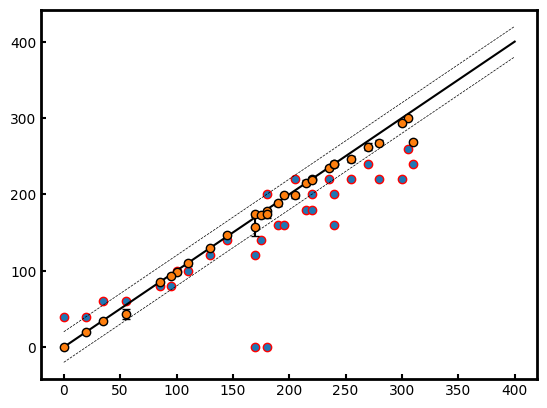

In [87]:
# mp_powers
# mp_velocities
# lr_results.keys()
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
cs = [color for color in colors[:3]]

plt.scatter(gt_mps, lr_mps, c= cs[0], edgecolor = 'r')
# plt.errorbar(gt_mps, diff_mps, yerr = diff_mp_std, c= cs[1], edgecolor = 'r')
# plt.scatter(gt_mps, ÷enc_mps, c= cs[2])
plt.errorbar(gt_mps, diff_mps, yerr=diff_mpstd, fmt="o", capsize = 3, ecolor = 'k' ,markeredgecolor = 'k', c = cs[1])

# plt.scatter(test_gt_mps, test_lr_mps, c = cs[0], marker = 's', edgecolor = 'k')
# plt.errorbar(test_gt_mps, test_diff_mps, yerr = diff_mp_std, c = cs[1], marker = 's', edgecolor = 'k')
# plt.scatter(test_gt_mps, test_enc_mps, c = cs[2], marker = 's')
plt.plot([0, 400], [20, 420], 'k--', linewidth = 0.5)
plt.plot([0, 400], [0, 400], 'k')
plt.plot([0, 400], [-20, 380], 'k--', linewidth = 0.5)
frame_tick()



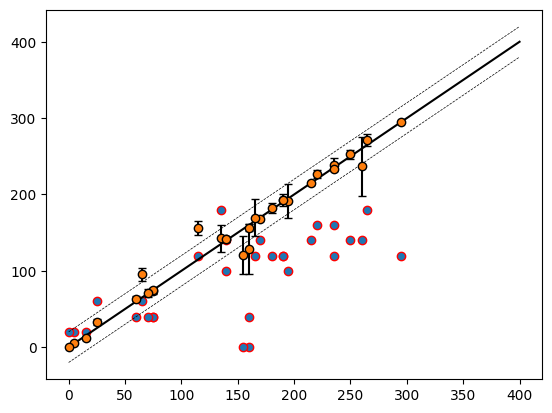

In [94]:
plt.errorbar(gt_kps, diff_kps, yerr=diff_kps_std, fmt="o", capsize = 3, ecolor = 'k' ,markeredgecolor = 'k', c = cs[1])
plt.scatter(gt_kps, lr_kps, c= cs[0], edgecolor = 'r')
plt.plot([0, 400], [20, 420], 'k--', linewidth = 0.5)
plt.plot([0, 400], [0, 400], 'k')
plt.plot([0, 400], [-20, 380], 'k--', linewidth = 0.5)

ValueError: 'yerr' (shape: (60,)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (30,))

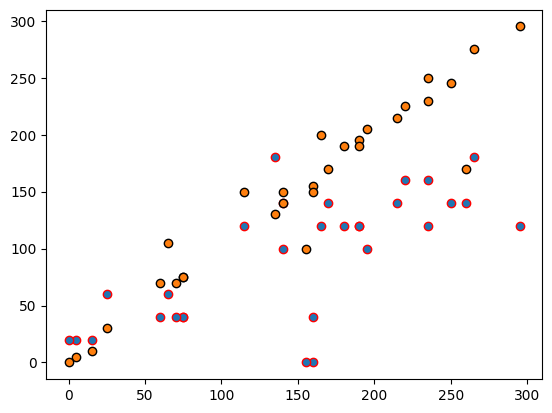

In [37]:
# mp_powers
# mp_velocities
# lr_results.keys()
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
cs = [color for color in colors[:3]]

plt.scatter(gt_kps, lr_kps, c= cs[0], edgecolor = 'r')
# plt.errorbar(gt_mps, diff_mps, yerr = diff_mp_std, c= cs[1], edgecolor = 'r')
# plt.scatter(gt_mps, ÷enc_mps, c= cs[2])
plt.errorbar(gt_kps, diff_kps, yerr=diff_kps_std, fmt="o", capsize = 3, ecolor = 'k' ,markeredgecolor = 'k', c = cs[1])

# plt.scatter(test_gt_mps, test_lr_mps, c = cs[0], marker = 's', edgecolor = 'k')
# plt.errorbar(test_gt_mps, test_diff_mps, yerr = diff_mp_std, c = cs[1], marker = 's', edgecolor = 'k')
# plt.scatter(test_gt_mps, test_enc_mps, c = cs[2], marker = 's')
plt.plot([0, 400], [20, 420], 'k--', linewidth = 0.5)
plt.plot([0, 400], [0, 400], 'k')
plt.plot([0, 400], [-20, 380], 'k--', linewidth = 0.5)
frame_tick()



In [30]:
# len(diff_kps_std)
import pickle
with open('train_diff_results.pkl', 'rb') as pickle_file:
    diff_results_global = pickle.load(pickle_file)
with open('test_diff_results.pkl', 'rb') as pickle_file:
    test_diff_results_global = pickle.load(pickle_file)

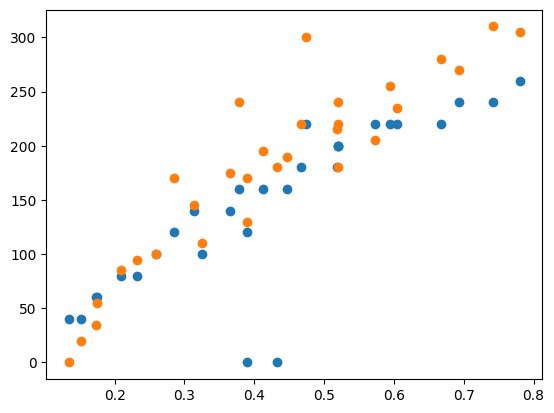

In [ ]:
# plt.scatter(test_gt_mps, test_lr_mps, c = cs[0], marker = 's', edgecolor = 'k')
plt.scatter(np.array(mp_powers)/np.array(mp_velocities), lr_mps)
plt.scatter(np.array(mp_powers)/np.array(mp_velocities), gt_mps)
# plt.scatter(np.array(mp_powers)/np.array(mp_velocities), diff_mps)


# len(kp_powers)
# kp_powers
# plt.scatter(test_gt_mps, test_diff_mps, c = cs[1], marker = 's', edgecolor = 'k')

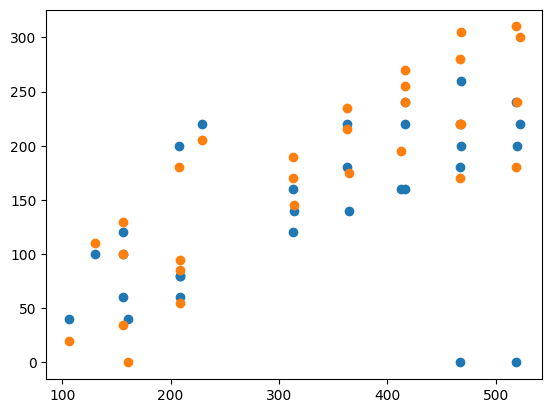

In [ ]:
plt.scatter(np.array(mp_powers), lr_mps)
plt.scatter(np.array(mp_powers), gt_mps)

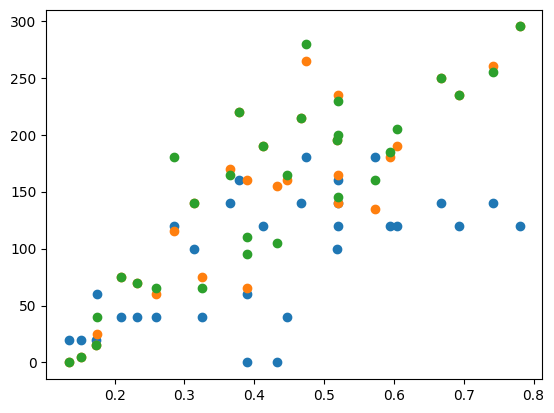

In [ ]:
plt.scatter(np.array(kp_powers)/np.array(kp_velocities), lr_kps)
plt.scatter(np.array(kp_powers)/np.array(kp_velocities), gt_kps)
plt.scatter(np.array(kp_powers)/np.array(kp_velocities), diff_kps)

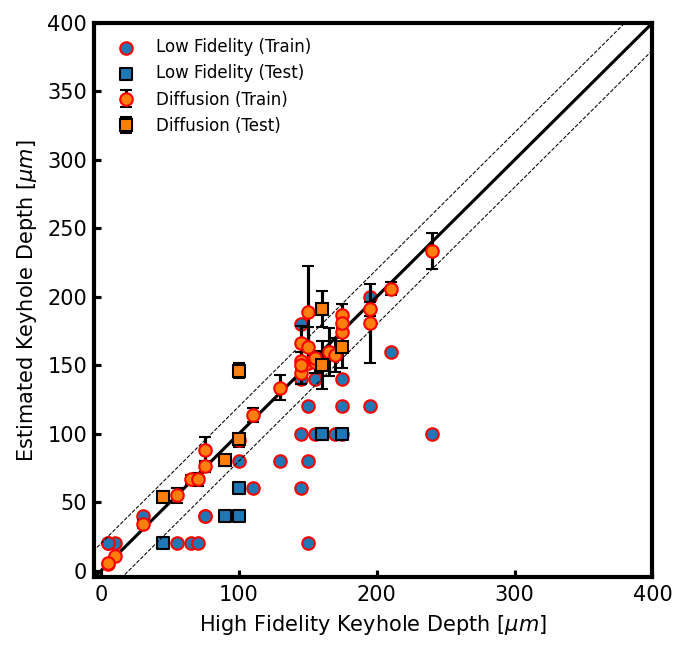

In [54]:
# plt.scatter(gt_mps, lr_kps)
# plt.scatter(gt_mps, diff_kps)
# plt.scatter(gt_mps, enc_kps)
plt.figure(dpi = 150, figsize = np.array([4,4])*1.2)
plt.plot([-10, 400], [-10, 400], 'k')

plt.scatter(gt_kps, lr_kps, c= cs[0], edgecolor = 'r', label = r'Low Fidelity (Train)')
plt.scatter(test_gt_kps, test_lr_kps, c = cs[0], marker = 's', edgecolor = 'k', label = r'Low Fidelity (Test)')
# plt.scatter(gt_mps, ÷enc_mps, c= cs[2])
plt.errorbar(gt_kps, diff_kps, yerr=diff_kps_std, fmt="o", capsize = 3, ecolor = 'k' ,markeredgecolor = 'r', c = cs[1], label = r'Diffusion (Train)')
# plt.scatter(gt_kps, diff_kps, c= cs[1], edgecolor = 'r', label = r'Diffusion (Train)')
# plt.scatter(test_gt_kps, test_diff_kps, c = cs[1], marker = 's', edgecolor = 'k', label = 'Diffusion (Test)')
plt.errorbar(test_gt_kps, test_diff_kps, yerr=test_diff_kps_std, fmt="s", capsize = 3, ecolor = 'k' ,markeredgecolor = 'k', c = cs[1], label = r'Diffusion (Test)')

plt.plot([0, 400], [-20, 380], 'k--', linewidth = 0.5)
plt.plot([0-100, 400], [20-100, 420], 'k--', linewidth = 0.5)
plt.xlim([-5, 400])
plt.ylim([-5, 400])
frame_tick()
plt.xlabel(r'High Fidelity Keyhole Depth [$\mu m$]')
plt.ylabel(r'Estimated Keyhole Depth [$\mu m$]')
legend()


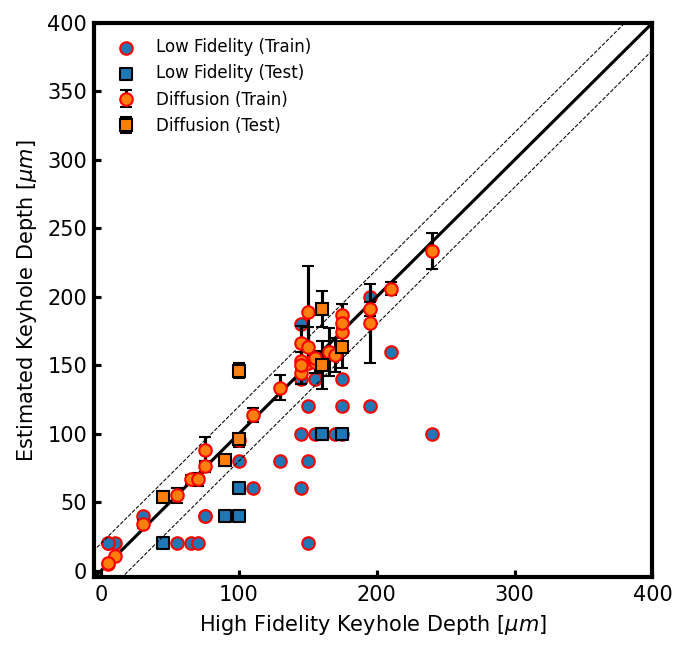

In [55]:
plt.figure(dpi = 150, figsize = np.array([4,4])*1.2)
plt.plot([-10, 400], [-10, 400], 'k')

plt.scatter(gt_kps, lr_kps, c= cs[0], edgecolor = 'r', label = r'Low Fidelity (Train)')
plt.scatter(test_gt_kps, test_lr_kps, c = cs[0], marker = 's', edgecolor = 'k', label = r'Low Fidelity (Test)')
# plt.scatter(gt_mps, ÷enc_mps, c= cs[2])
plt.errorbar(gt_kps, diff_kps, yerr=diff_kps_std, fmt="o", capsize = 3, ecolor = 'k' ,markeredgecolor = 'r', c = cs[1], label = r'Diffusion (Train)')
# plt.scatter(gt_kps, diff_kps, c= cs[1], edgecolor = 'r', label = r'Diffusion (Train)')
# plt.scatter(test_gt_kps, test_diff_kps, c = cs[1], marker = 's', edgecolor = 'k', label = 'Diffusion (Test)')
plt.errorbar(test_gt_kps, test_diff_kps, yerr=test_diff_kps_std, fmt="s", capsize = 3, ecolor = 'k' ,markeredgecolor = 'k', c = cs[1], label = r'Diffusion (Test)')

plt.plot([0, 400], [-20, 380], 'k--', linewidth = 0.5)
plt.plot([0-100, 400], [20-100, 420], 'k--', linewidth = 0.5)
plt.xlim([-5, 400])
plt.ylim([-5, 400])
frame_tick()
plt.xlabel(r'High Fidelity Keyhole Depth [$\mu m$]')
plt.ylabel(r'Estimated Keyhole Depth [$\mu m$]')
legend()

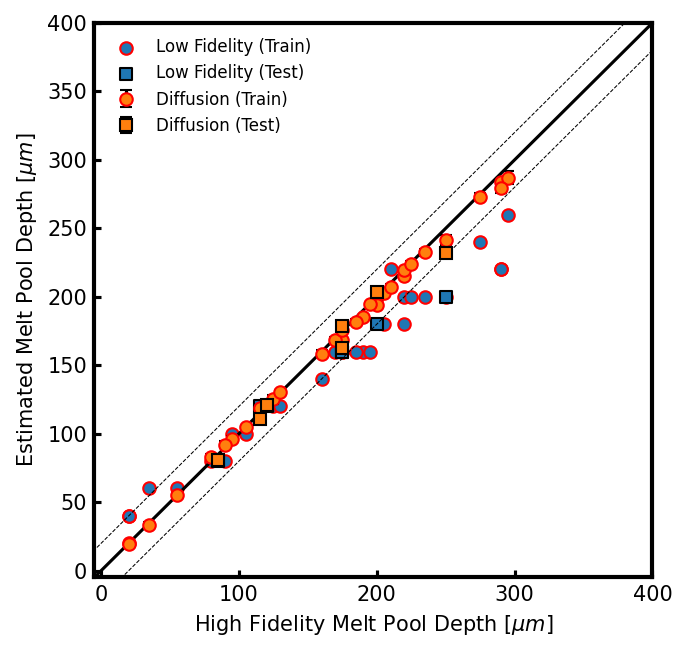

In [56]:
plt.figure(dpi = 150, figsize = np.array([4,4])*1.2)
plt.plot([-10, 400], [-10, 400], 'k')

plt.scatter(gt_mps, lr_mps, c= cs[0], edgecolor = 'r', label = r'Low Fidelity (Train)')
plt.scatter(test_gt_mps, test_lr_mps, c = cs[0], marker = 's', edgecolor = 'k', label = r'Low Fidelity (Test)')
# plt.scatter(gt_mps, ÷enc_mps, c= cs[2])
plt.errorbar(gt_mps, diff_mps, yerr=diff_mpstd, fmt="o", capsize = 3, ecolor = 'k' ,markeredgecolor = 'r', c = cs[1], label = r'Diffusion (Train)')
plt.errorbar(test_gt_mps, test_diff_mps, yerr=test_diff_mps_std, fmt="s", capsize = 3, ecolor = 'k' ,markeredgecolor = 'k', c = cs[1], label = r'Diffusion (Test)')

# plt.scatter(gt_mps, diff_mps, c= cs[1], edgecolor = 'r', label = r'Diffusion (Train)')
# plt.scatter(test_gt_mps, test_diff_mps, c = cs[1], marker = 's', edgecolor = 'k', label = 'Diffusion (Test)')
plt.plot([0, 400], [-20, 380], 'k--', linewidth = 0.5)
plt.plot([0-100, 400], [20-100, 420], 'k--', linewidth = 0.5)
plt.xlim([-5, 400])
plt.ylim([-5, 400])
frame_tick()
plt.xlabel(r'High Fidelity Melt Pool Depth [$\mu m$]')
plt.ylabel(r'Estimated Melt Pool Depth [$\mu m$]')
legend()


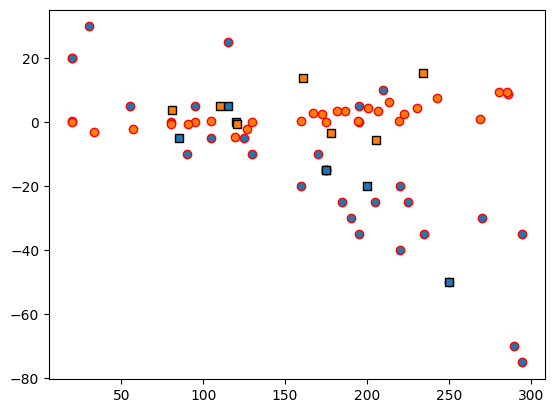

In [47]:
plt.scatter(gt_mps, np.array(lr_mps) - np.array(gt_mps) , c= cs[0], edgecolor = 'r', label = r'Low Fidelity (Train)')
plt.scatter(test_gt_mps, np.array(test_lr_mps) - np.array(test_gt_mps), c = cs[0], marker = 's', edgecolor = 'k', label = r'Low Fidelity (Test)')

plt.scatter(diff_mps, np.array(gt_mps) - np.array(diff_mps) , c= cs[1], edgecolor = 'r', label = r'Low Fidelity (Train)')
plt.scatter(test_diff_mps, np.array(test_gt_mps) - np.array(test_diff_mps), c = cs[1], marker = 's', edgecolor = 'k', label = r'Low Fidelity (Test)')
# plt.scatter(gt_mps, ÷enc_mps, c= cs[2])

# plt.scatter(gt_mps, diff_mps, c= cs[1], edgecolor = 'r', label = r'Diffusion Model (Train)')
# plt.scatter(test_gt_mps, test_diff_mps, c = cs[1], marker = 's', edgecolor = 'k', label = 'Diffusion Model (Test)')

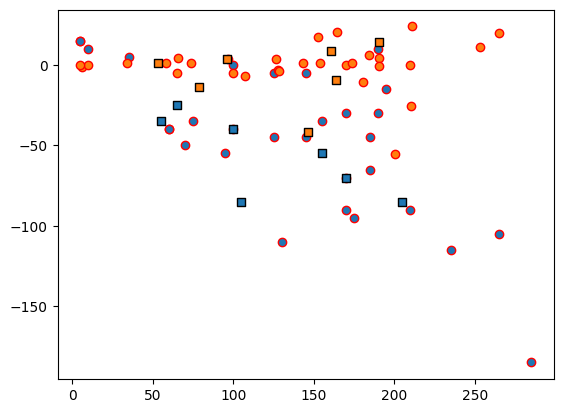

In [49]:
plt.scatter(gt_kps, np.array(lr_kps) - np.array(gt_kps) , c= cs[0], edgecolor = 'r', label = r'Low Fidelity (Train)')
plt.scatter(test_gt_kps, np.array(test_lr_kps) - np.array(test_gt_kps), c = cs[0], marker = 's', edgecolor = 'k', label = r'Low Fidelity (Test)')

plt.scatter(diff_kps, np.array(gt_kps) - np.array(diff_kps) , c= cs[1], edgecolor = 'r', label = r'Low Fidelity (Train)')
plt.scatter(test_diff_kps, np.array(test_gt_kps) - np.array(test_diff_kps), c = cs[1], marker = 's', edgecolor = 'k', label = r'Low Fidelity (Test)')

In [58]:
np.mean( np.abs(np.array(gt_kps) - np.array(diff_kps)))

6.45

In [61]:
np.mean( np.abs(np.array(test_gt_kps) - np.array(test_diff_kps)))


17.357142857142858

In [65]:
np.mean(np.abs(np.array(test_gt_kps) - np.array(test_diff_kps)))

13.285714285714286

In [63]:
np.mean( np.abs(np.array(test_gt_kps) - np.array(test_diff_kps)))

13.285714285714286

In [59]:
np.mean( np.abs(np.array(gt_mps) - np.array(diff_mps)))


2.8666666666666667

In [60]:
np.mean( np.abs(np.array(test_gt_mps) - np.array(test_diff_mps)))


6.825396825396824

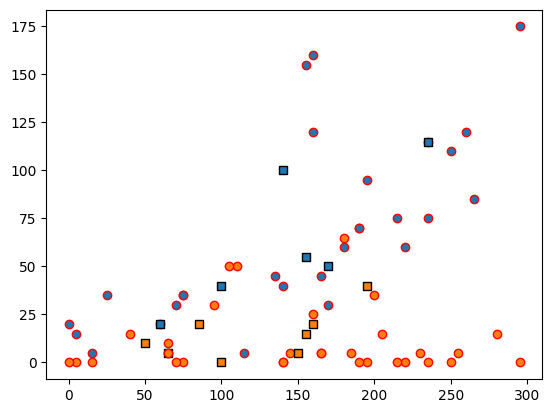

In [ ]:
plt.scatter(gt_kps, np.abs(np.array(lr_kps) - np.array(gt_kps)) , c= cs[0], edgecolor = 'r', label = r'Low Fidelity (Train)')
plt.scatter(test_gt_kps, np.abs(np.array(test_lr_kps) - np.array(test_gt_kps)), c = cs[0], marker = 's', edgecolor = 'k', label = r'Low Fidelity (Test)')

plt.scatter(diff_kps, np.abs(np.array(gt_kps) - np.array(diff_kps)) , c= cs[1], edgecolor = 'r', label = r'Low Fidelity (Train)')
plt.scatter(test_diff_kps, np.abs(np.array(test_gt_kps) - np.array(test_diff_kps)), c = cs[1], marker = 's', edgecolor = 'k', label = r'Low Fidelity (Test)')

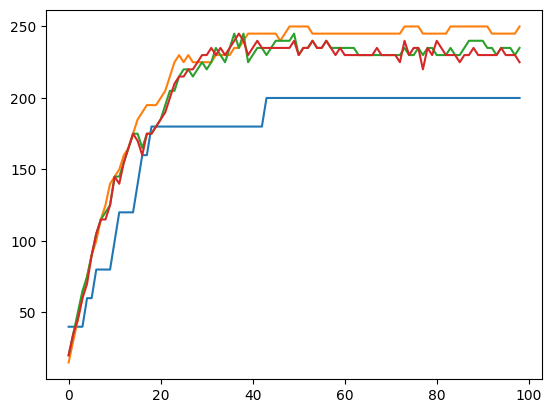

In [ ]:
key = 'depth_power520.0vel900.0'
plt.plot(lr_results[key])
plt.plot(gt_results[key])
plt.plot(enc_results[key])
plt.plot(diff_results[key])



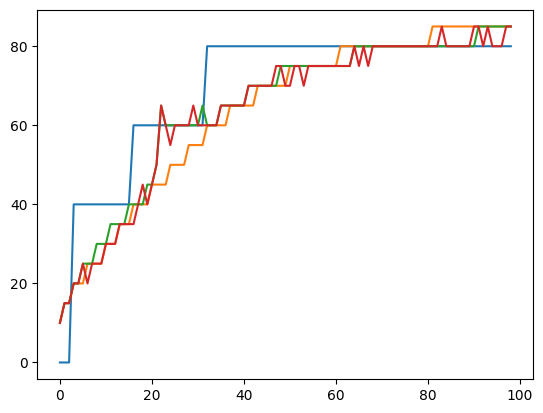

In [ ]:
plt.plot(lr_results['depth_power156.0vel700.0'])
plt.plot(gt_results['depth_power156.0vel700.0'])
plt.plot(enc_results['depth_power156.0vel700.0'])
plt.plot(diff_results['depth_power156.0vel700.0'])


In [ ]:
np.fft.fftfreq(np.array(signal).size, d = time_signal[1] - time_signal[0])

key_power156.0vel700.0


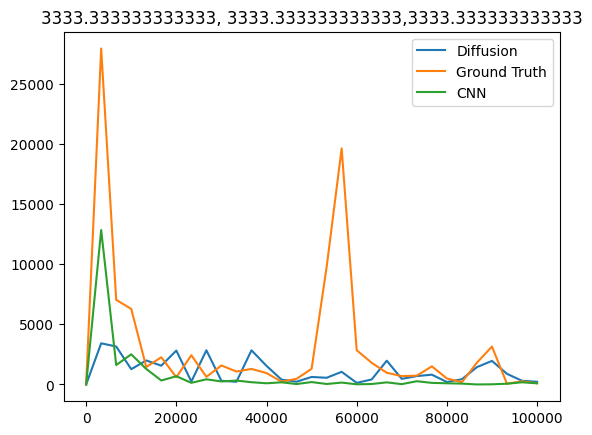

key_power183.0vel600.0


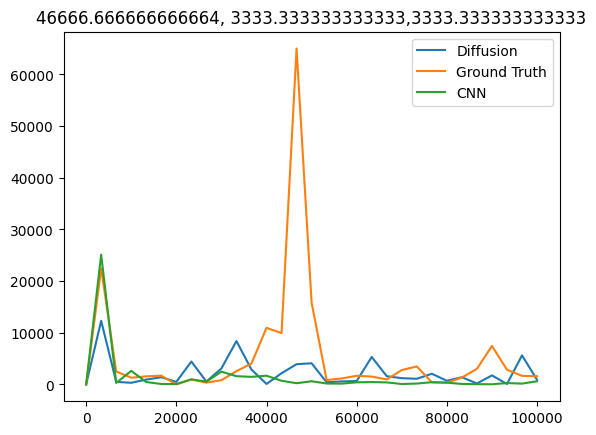

key_power260.0vel900.0


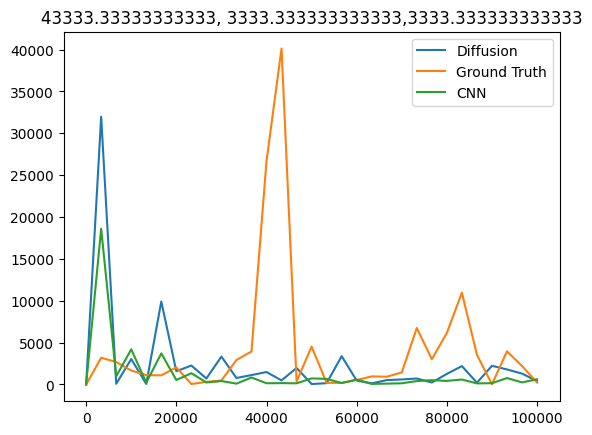

key_power261.0vel600.0


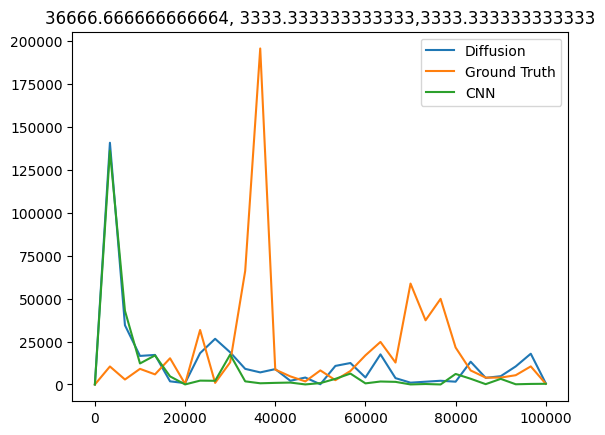

key_power364.0vel900.0


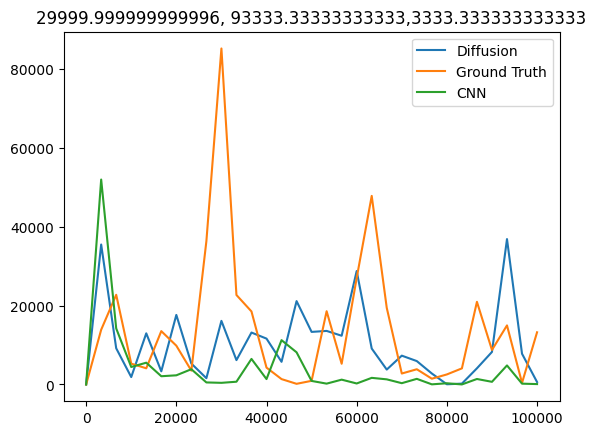

key_power415.0vel900.0


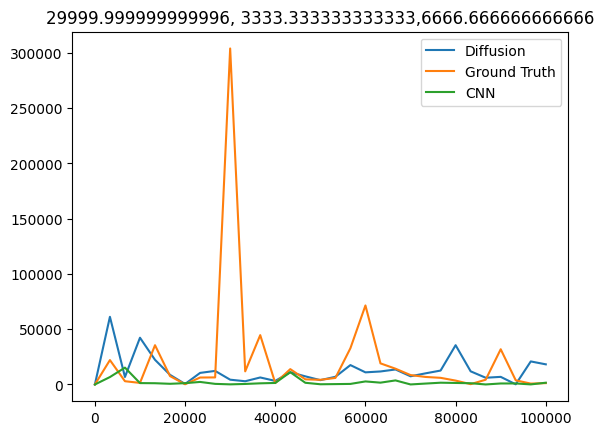

key_power520.0vel900.0


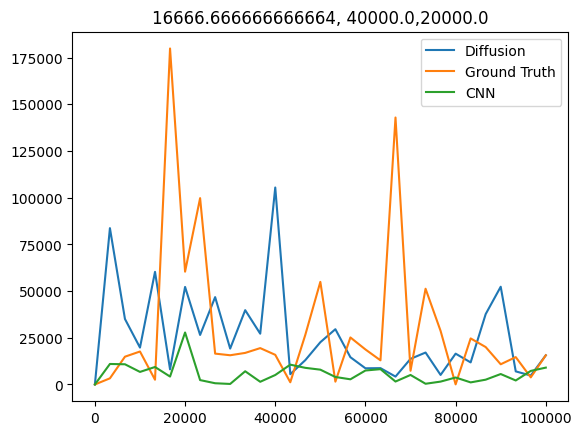

In [ ]:
def calc_fft_freq(signal, timestep = 5e-6):
    fft = np.fft.rfft(signal - np.mean(signal))
    power_spectrum = np.abs(fft)**2
    time_signal = np.arange(len(signal))*timestep
    freq = np.fft.rfftfreq(np.array(signal).size, d = time_signal[1] - time_signal[0])
    dominant_frequency = freq[np.argmax(power_spectrum)]
    return dominant_frequency, freq, power_spectrum
for key in diff_results.keys():
    if 'key' in key:
        print(key)



        gt_dominant_frequency, gt_freq, gt_power_spectrum = calc_fft_freq(gt_results[key][30:90])
        diff_dominant_frequency, diff_freq, diff_power_spectrum = calc_fft_freq(diff_results[key][30:90])
        enc_dominant_frequency, enc_freq, enc_power_spectrum = calc_fft_freq(enc_results[key][30:90])

        # plt.plot(gt_results[key][30:80])
        # plt.plot(diff_results[key][30:80])
        # plt.plot(enc_results[key][30:80])
        # plt.show()
        plt.title('{}, {},{}'.format(gt_dominant_frequency,diff_dominant_frequency, enc_dominant_frequency ))
        gt_amp = np.sqrt(np.mean((gt_results[key][30:80] - np.mean(gt_results[key][30:80]))**2))
        diff_amp = np.sqrt(np.mean((diff_results[key][30:80] - np.mean(diff_results[key][30:80]))**2))

        # plt.title('{}, {}'.format(np.sqrt(np.mean(gt_results[key][30:80])),np.sqrt(np.mean(diff_results[key][30:80])) ))
        # plt.title('{},{}'.format(gt_amp,diff_amp))
        plt.plot(diff_freq, diff_power_spectrum, label = "Diffusion")
        
        plt.plot(gt_freq, gt_power_spectrum, label = "Ground Truth")
        plt.plot(enc_freq, enc_power_spectrum, label = 'CNN')
        plt.legend()
        # plt.show()

        # plt.title(diff_freq[np.argmax(diff_power_spectrum)])

        plt.show()


In [ ]:
diff_results_global[trial_key].keys()

dict_keys(['key_power156.0vel700.0', 'depth_power156.0vel700.0', 'key_power183.0vel600.0', 'depth_power183.0vel600.0', 'key_power260.0vel900.0', 'depth_power260.0vel900.0', 'key_power261.0vel600.0', 'depth_power261.0vel600.0', 'key_power364.0vel900.0', 'depth_power364.0vel900.0', 'key_power415.0vel900.0', 'depth_power415.0vel900.0', 'key_power520.0vel900.0', 'depth_power520.0vel900.0'])

In [ ]:
parameters = list(diff_results_global[trial_key].keys())[0].split('key_power')[-1].split('vel')

['156.0', '700.0']

In [ ]:

diff_amps_global = []
for trial_key in diff_results_global.keys():
    diff_results = diff_results_global[trial_key]
    enc_amps = []
    gt_amps = []
    diff_amps = []
    powers = []
    velocities = []
    for key in diff_results_global[trial_key].keys():
        print(key, gt_results.keys())
    
        if 'key' in key:
            # plt.figure(dpi = 150, figsize = np.array([4,3])*1.3)
            # plt.plot(np.arange(len(diff_results[key]))*5, diff_results[key], '--')
            # plt.plot(np.arange(len(diff_results[key]))*5, gt_results[key], 'k-')
            # plt.plot(np.arange(len(diff_results[key]))*5, enc_results[key], '--')
            gt_amp = np.sqrt(np.mean((gt_results[key][30:80] - np.mean(gt_results[key][30:80]))**2))
            diff_amp = np.sqrt(np.mean((diff_results[key][30:80] - np.mean(diff_results[key][30:80]))**2))
            enc_amp  = np.sqrt(np.mean((enc_results[key][30:80] - np.mean(enc_results[key][30:80]))**2))
            gt_amps.append(gt_amp)
            enc_amps.append(enc_amp)
            diff_amps.append(diff_amp)
            print(len(diff_amps))
            parameters = key.split('key_power')[-1].split('vel')
            powers.append(float(parameters[0]))
            velocities.append(float(parameters[1]))
            # frame_tick()
            # legend()
            # plt.xlim([0, 500])
            # plt.ylim([0, 250])
            # plt.xlabel(r'Time [$\mu s$]')
            # plt.ylabel(r'Keyhole Depth [$\mu m$]')

            # plt.show()
        # if 'depth' in key:
        #     plt.figure(dpi = 150, figsize = np.array([4,3])*1.3)

        #     plt.plot(np.arange(len(diff_results[key]))*5, diff_results[key], '--')
        #     plt.plot(np.arange(len(diff_results[key]))*5, gt_results[key], 'k-')
        #     plt.plot(np.arange(len(diff_results[key]))*5, enc_results[key], '--')
        #     plt.ylim([0, 300])
        #     frame_tick()
        #     plt.xlabel(r'Time [$\mu s$]')
        #     plt.ylabel(r'Melt Pool Depth [$\mu m$]')

        #     legend()
        #     plt.show()
    diff_amps_global.append(diff_amps)


key_power156.0vel700.0 dict_keys(['key_power156.0vel700.0', 'depth_power156.0vel700.0', 'key_power183.0vel600.0', 'depth_power183.0vel600.0', 'key_power260.0vel900.0', 'depth_power260.0vel900.0', 'key_power261.0vel600.0', 'depth_power261.0vel600.0', 'key_power364.0vel900.0', 'depth_power364.0vel900.0', 'key_power415.0vel900.0', 'depth_power415.0vel900.0', 'key_power520.0vel900.0', 'depth_power520.0vel900.0'])
1
depth_power156.0vel700.0 dict_keys(['key_power156.0vel700.0', 'depth_power156.0vel700.0', 'key_power183.0vel600.0', 'depth_power183.0vel600.0', 'key_power260.0vel900.0', 'depth_power260.0vel900.0', 'key_power261.0vel600.0', 'depth_power261.0vel600.0', 'key_power364.0vel900.0', 'depth_power364.0vel900.0', 'key_power415.0vel900.0', 'depth_power415.0vel900.0', 'key_power520.0vel900.0', 'depth_power520.0vel900.0'])
key_power183.0vel600.0 dict_keys(['key_power156.0vel700.0', 'depth_power156.0vel700.0', 'key_power183.0vel600.0', 'depth_power183.0vel600.0', 'key_power260.0vel900.0', 'd

In [ ]:
powers

['156.0', '183.0', '260.0', '261.0', '364.0', '415.0', '520.0']

In [ ]:
mean_diff = np.array(diff_amps_global).mean(axis = 0)
std_diff =  np.array(diff_amps_global).std(axis = 0)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


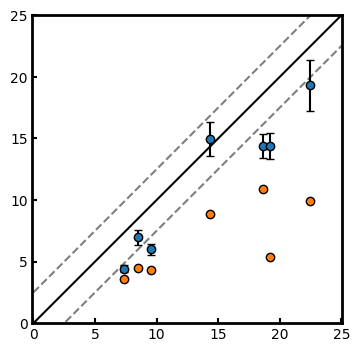

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


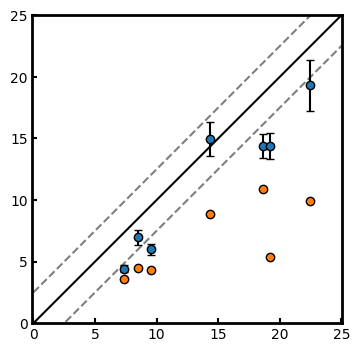

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


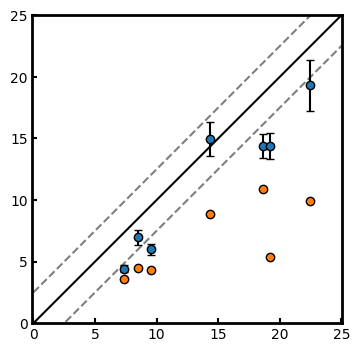

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


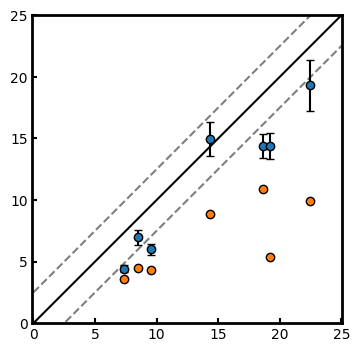

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


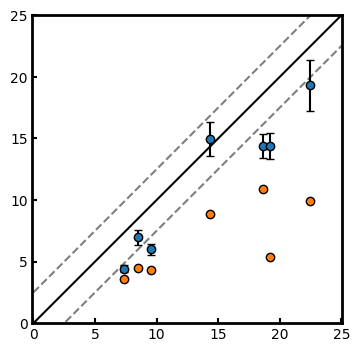

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


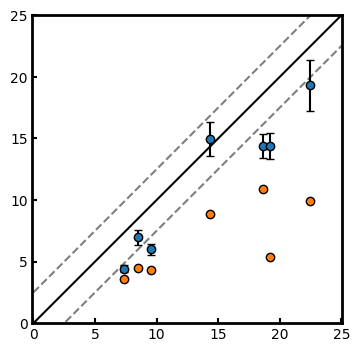

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


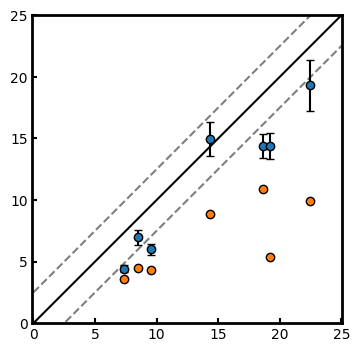

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


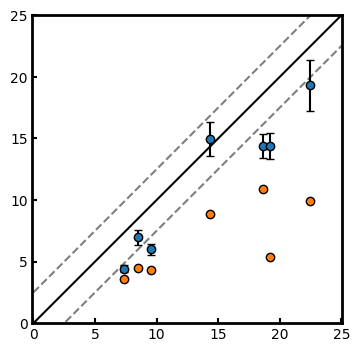

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


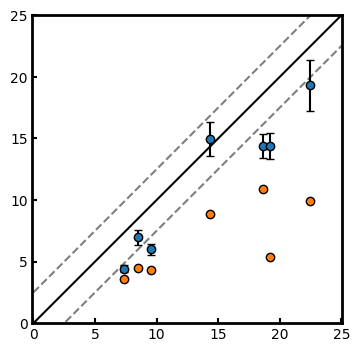

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


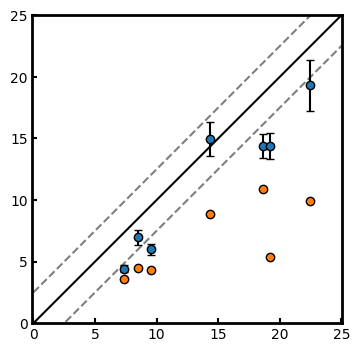

In [ ]:
for diff_amps in diff_amps_global:
    plt.figure(figsize = [4,4])
    plt.errorbar(gt_amps, mean_diff, yerr=std_diff, fmt="o", capsize = 3, ecolor = 'k' ,markeredgecolor = 'k')
    # plt.scatter(gt_amps, mean_diff, edgecolor = 'k' , s = 80)
    plt.plot(gt_amps, enc_amps,'o', markeredgecolor = 'k')

    plt.plot([0, 30], [0, 30], 'k-')
    # plt.plot([0, 30], [-5, 30-5], 'k--', alpha= 0.5)
    plt.plot([0, 30], [2.5, 30+2.5], 'k--', alpha= 0.5)
    plt.plot([0, 30], [-2.5, 30-2.5], 'k--', alpha= 0.5)
    plt.xlabel('')


    plt.axis('equal')
    plt.xlim([0,25])
    plt.ylim([0,25])
    frame_tick()
    legend()
    plt.show()

In [ ]:
for trial_key in diff_results_global.keys():
    print(len(diff_results_global[trial_key]))

14
14
14
14
14


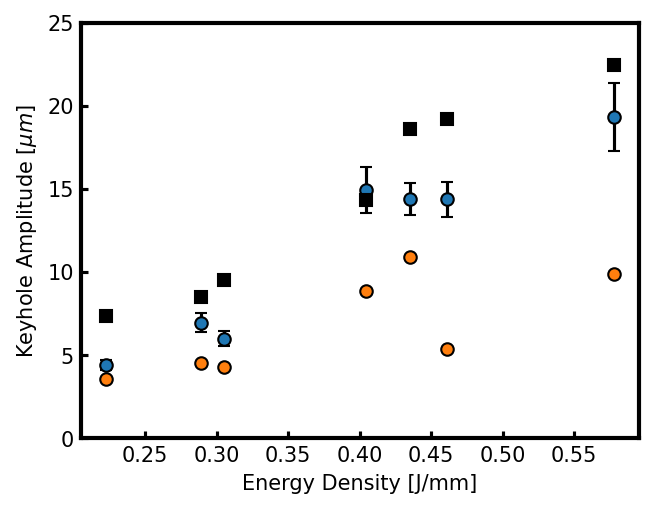

In [ ]:
plt.figure(dpi = 150, figsize = np.array([4,3])*1.2)
plt.ylim([0,25])
# plt.grid()
diff_p = np.poly1d()
plt.errorbar(np.array(powers)/np.array(velocities), mean_diff, yerr=std_diff, fmt="o", capsize = 3, ecolor = 'k' ,markeredgecolor = 'k')
plt.errorbar(np.array(powers)/np.array(velocities), enc_amps, fmt="o", capsize = 3, ecolor = 'k' ,markeredgecolor = 'k')
plt.errorbar(np.array(powers)/np.array(velocities), gt_amps, fmt="ks", capsize = 3, ecolor = 'k' ,markeredgecolor = 'k')
plt.xlabel('Energy Density [J/mm]')
plt.ylabel('Keyhole Amplitude $[\mu m]$')

frame_tick()


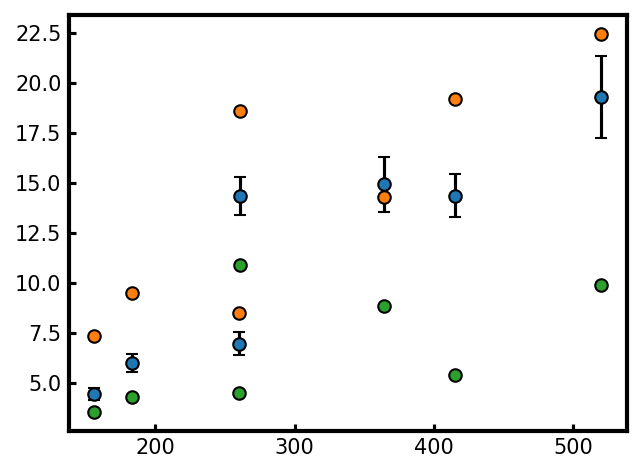

In [ ]:
plt.figure(dpi = 150, figsize = np.array([4,3])*1.2)
plt.errorbar(np.array(powers), mean_diff, yerr=std_diff, fmt="o", capsize = 3, ecolor = 'k' ,markeredgecolor = 'k')
plt.errorbar(np.array(powers), gt_amps, fmt="o", capsize = 3, ecolor = 'k' ,markeredgecolor = 'k')
plt.errorbar(np.array(powers), enc_amps, fmt="o", capsize = 3, ecolor = 'k' ,markeredgecolor = 'k')
frame_tick()


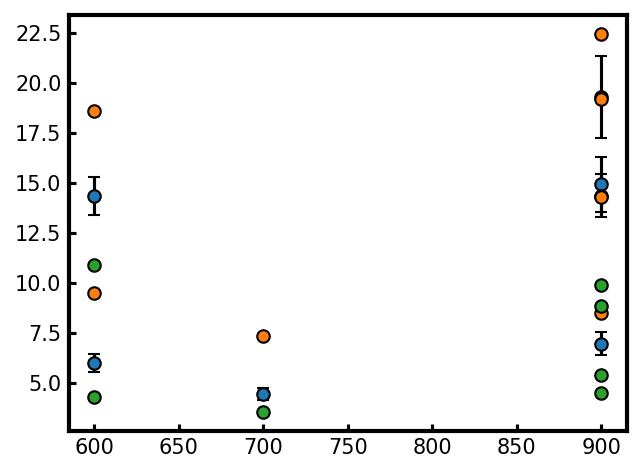

In [ ]:
plt.figure(dpi = 150, figsize = np.array([4,3])*1.2)
plt.errorbar(np.array(velocities), mean_diff, yerr=std_diff, fmt="o", capsize = 3, ecolor = 'k' ,markeredgecolor = 'k')
plt.errorbar(np.array(velocities), gt_amps, fmt="o", capsize = 3, ecolor = 'k' ,markeredgecolor = 'k')
plt.errorbar(np.array(velocities), enc_amps, fmt="o", capsize = 3, ecolor = 'k' ,markeredgecolor = 'k')
frame_tick()
